<a href="https://colab.research.google.com/github/izabelaandrade-pos/mvp-puc-machine-learning/blob/main/Sprint3_MVP_Machine_Learning_Logaritmico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Machine Learning & Analytics**

**Nome:** Izabela Gregório de Andrade

**Matrícula:** 4052025001738

**Data:** 05/07/2026

**Dataset:** [Used Cars](https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-analise-dados/refs/heads/main/used_cars.csv)

**Tipo de problema:** Regressão

#1. Definição do Problema

## 1.1 Descrição do Problema

O presente projeto objetiva estudar como um conjunto de características de veículos usados (como marca, modelo e quilometragem) influencia na determinação de seu valor de mercado.

A motivação para este estudo é contribuir para que indivíduos interessados em vender seus automóveis usados estejam melhor informados na escolha do preço de seus anúncios. Uma estimativa assertiva do valor de venda pode potencializar as negociações, reduzindo o tempo de permanência do veículo à venda.

Este projeto foi iniciado na Sprint de Análise de Dados e Boas Práticas, com um estudo focado na Análise e Pré-Processamento dos dados, disponível em: [Link MVP Parte 1](https://github.com/izabelaandrade-pos/mvp-puc-analise-dados.git)



Iremos retormar os principais tratamentos elencados anteriormente e prosseguir para a formulação de um modelo de regressão capaz de cumprir o objetivo proposto abaixo.

## 1.2 Objetivo do MVP

O objetivo final deste MVP será produzir um modelo de regressão que seja capaz de avaliar o preço de um veículo usado a partir de características estruturais e de mercado relevantes, como marca, modelo, quilometragem, idade do veículo, especificações do motor e histórico de sinistros.

Este modelo será comparado com um baseline estatístico ingênuo (Dummy Regressor baseado na mediana), e com diversas abordagens de modelos de regressão (como regressão linear, árvore de decisão, KNN, SVM e ensembles) para entender qual apresenta melhor performance. Além disso, será feita a otimização de parâmetros do algoritmo selecionado.

## 1.3 Tipo de Problema:

Este é um problema de **regressão supervisionada**. Dado um conjunto de atributos de um veículo (como marca, modelo, ano, quilometragem, características do motor, combustível, cor interna e externa, se sofreu ou não sinistro, etc), o objetivo é prever o seu preço de mercado.

Nossa variável target está contida na coluna *price*, variável numérica e contínua.

A precificação de veículos usados é idealmente tratada por meio de Machine Learning devido à natureza complexa do problema. O valor de mercado de um automóvel não depende de um único fator isolado, mas sim da combinação simultânea de interações não lineares entre múltiplos atributos (como o impacto conjunto da alta quilometragem combinado a um histórico de sinistro em uma marca de luxo). Abordagens tradicionais baseadas em regras estáticas ou tabelas fixas falham em capturar essas nuances de mercado, tornando os algoritmos de aprendizado de máquina supervisionado indispensáveis para generalizar e estimar preços melhor precisão.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses Levantadas:**

1. Tendência de Depreciação por Idade: Quanto mais antigos os modelos, menor o preço do automóvel.

2. Relação entre Uso e Valor: Veículos com maior quilometragem acumulada apresentam preços inferiores aos de baixa quilometragem.

3. Impacto do Histórico de Acidentes: O registro de acidentes prévios desvaloriza o automóvel em comparação com veículos similares sem sinistro.

**Critérios de sucesso:**

- Métrica Principal: MAPE - Escolhida por sua alta interpretabilidade comercial e aderência ao público-alvo (vendedores individuais), medindo diretamente o desvio percentual médio esperado nas estimativas de preço, independentemente da faixa de valor do veículo.

- Métrica Secundária: RMSE — Mantida como métrica de controle estatístico para monitorar e penalizar desvios extremos em valores absolutos, garantindo a estabilidade matemática global do algoritmo.

- Resultado Mínimo Esperado: Alcançar um MAPE abaixo de 25% nos melhores modelos e reduzir o RMSE em pelo menos 20% em relação ao Baseline.

- Restrição prática: tempo de treino e custo computacional







# 2. Ambiente, bibliotecas e reprodutibilidade

In [462]:
!pip install -q imbalanced-learn

In [463]:
!pip install -q xgboost

In [464]:
# === Setup básico e reprodutibilidade ===

import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV, cross_val_score, cross_val_predict, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, TargetEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from imblearn.pipeline import Pipeline # Importamos o Pipeline do imblearn para permitir remoção de linhas!
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 7


## 2.1 Funções Auxiliares

In [465]:
# Define função que apresenta a distribuição de frequencias de uma coluna
# Para efeitos de relatório, vamos exibir apenas as 50 classes mais frequentes

def analisar_distribuicao(df, coluna):

    # Cálculo da frequência absoluta
    contagem = df[coluna].value_counts(dropna=False)

    # Cálculo da frequência relativa
    porcentagem = df[coluna].value_counts(dropna=False, normalize=True) * 100

    # Criação de um DataFrame para exibição
    distribuicao = pd.DataFrame({'Frequência Absoluta': contagem, 'Frequência Relativa (%)': porcentagem.round(2)})

    print(f"--- Análise da Variável: {coluna} ---")
    print(f"Total de classes únicas (incluindo NaN): {len(contagem)}\n")

    # Exibe primeiras 50 linhas da distribuição
    print(distribuicao.head(50).to_string())

In [466]:
# Define função que apresenta as 50 classes mais frequentes de uma coluna em um gráfico de barras

def grafico_distribuicao(df, coluna):

    # Cria uma cópia temporária preenchendo os NaNs da coluna analisada
    df_temp = df.copy()
    df_temp[coluna] = df_temp[coluna].fillna('Não Informado')

    # Seleciona 50 classes mais frequentes
    top_50 = df_temp[coluna].value_counts(dropna=False).head(50)

    # Desenho do gráfico de barras
    plt.figure(figsize=(15, 5))
    sns.barplot(x=top_50.index, y=top_50.values, palette='viridis', hue=top_50.index, legend=False)

    # Rotaciona legenda
    plt.xticks(rotation=45, ha='right')

    # Inclui títulos
    plt.title(f'Top categorias: {coluna}')
    plt.xlabel('Classes')
    plt.ylabel('Quantidade de Carros')

    # Exibe o gráfico
    plt.tight_layout()
    plt.show()

In [467]:
# Define função que cria gráfico boxplot dos preços de veículos, nas classes da variável escolhida

def boxplot_price (df, coluna_x):
    # Cria espaço para o gráfico
    plt.figure(figsize=(9, 5))

    # Criamos uma cópia temporária preenchendo os NaNs da coluna analisada
    df_temp = df.copy()
    df_temp[coluna_x] = df_temp[coluna_x].fillna('Não Informado')

    # Cria o gráfico Boxplot
    sns.boxplot(x=coluna_x, y='price', data=df_temp,
                palette='viridis',
                hue=coluna_x,
                legend=False)

    # Ajusta a escala
    plt.yscale('log') # Escala logarítmica para lidar com outliers extremos

    # Inclui os títulos
    plt.title(f'Distribuição de Preços por {coluna_x} (Escala Log)', fontsize=14)
    plt.xlabel(f'{coluna_x}', fontsize=12)
    plt.ylabel('Preço ($)', fontsize=12)


#3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset "Used Car Price Prediction" é composto por informações coletadas via web scraping no marketplace https://www.cars.com.

Estes dados foram disponibilizados na plataforma Kaggle, através do endereço: https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset/data  sob licença  [Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).

Para fins deste projeto, o arquivo CSV foi espelhado no respectivo repositório GitHub para garantir a reprodutibilidade da análise, estando disponível em: https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-machine-learning/refs/heads/main/used_cars.csv

Este conjunto de dados reflete **anúncios reais e ativos** no **marketplace americano cars.com** no **ano de 2023**, servindo como estudo da dinâmica de preços naquele mercado e período de tempo específicos.


## 3.2 Carga de dados

In [468]:
# Leitura dos dados armazenados no GitHub e cópia dos mesmos em um dataframe

url = 'https://raw.githubusercontent.com/izabelaandrade-pos/mvp-puc-machine-learning/refs/heads/main/used_cars.csv'

df_cars = pd.read_csv(url)


In [469]:
# Visualizar as primeiras linhas do dataframe

df_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 3.3 Visão geral do dataset

In [470]:
# Descrição do número de linhas e colunas do dataset, e tipo de dado de cada atributo

print("Formato do dataset:", df_cars.shape)
print("\nTipos de dados:")
display(df_cars.dtypes.to_frame("tipo"))

Formato do dataset: (4009, 12)

Tipos de dados:


,tipo
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [471]:
# Contabilização de missings (nulos) em cada coluna

print("\nValores ausentes por coluna:")
display(df_cars.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [472]:
# Contabilização de registros duplicados na base original

print("\nDuplicatas:", df_cars.duplicated().sum())


Duplicatas: 0


O dataset Used Cars é composto por 4.009 instâncias e 12 colunas, sendo a última coluna (*price*) o atributo target do problema de regressão.

Podemos notar que os atributos *fuel_type*, *accident* e *clean_title* apresentam dados faltantes (nulos), que serão posteriormente tratados. Verificamos ainda que a base não apresenta registros duplicados.

Em uma análise inicial da tipagem dos dados, observa-se que 11 colunas são identificadas como o tipo object (strings), enquanto apenas a coluna *model_year* é reconhecida nativamente como um valor numérico (inteiro).

Entretanto, do ponto de vista semântico, as variáveis *milage* (quilometragem) e *price* (preço) são, por natureza, variáveis numéricas contínuas. A tipagem atual como texto deve-se à presença de caracteres especiais (como símbolos de moeda e unidades de medida). Portanto, será necessária uma etapa de limpeza e conversão para que estas colunas assumam valores numéricos. As demais variáveis do conjunto são genuinamente categóricas.

In [473]:
# Conversão das colunas milage e price em dados numéricos

# Limpeza da coluna 'milage' de tudo que não for dígitos (removendo "mi.", vírgulas e espaços)
df_cars['milage'] = df_cars['milage'].str.replace(r'[^\d]', '', regex=True).astype(float)

# Limpeza da coluna 'price' de tudo que não for dígitos (removendo "$", vírgulas e espaços)
df_cars['price'] = df_cars['price'].str.replace(r'[^\d]', '', regex=True).astype(float)

# Verificando a transformação
print('Info atualizada:\n')
display(df_cars.dtypes.to_frame("tipo"))

Info atualizada:



,tipo
brand,object
model,object
model_year,int64
milage,float64
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [474]:
# Primeiras linhas após transformação de milage e price

df_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


## 3.3 Dicionário de dados

O dataset em estudo apresenta 4.009 instâncias, em que cada uma representa o anúncio de um veículo único, e inclui doze atributos distintos descritos abaixo:

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| brand | categórica | Identifica o nome da marca ou empresa que produziu o veículo. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering. |
| model | categórica | Identifica o modelo específico de cada veículo. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering.|
| model_year | numérica | Apresenta o ano de fabricação dos veículos, crucial para avaliar a depreciação e os avanços tecnológicos. | sim | Transformada em idade do veículo. Variável importante para o modelo, principlamente após tratamento de outliers. |
| milage | numérica | Obtém a quilometragem (em milhas) de cada veículo, um indicador fundamental de desgaste e possíveis requisitos de manutenção. | sim | Variável importante para o modelo, principlamente após tratamento de outliers. |
| fuel_type | categórica | Informa sobre o tipo de combustível que os veículos utilizam, seja gasolina, diesel, elétrico ou híbrido. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering. |
| engine| categórica | Detalha as especificações do motor, esclarecendo aspectos de desempenho e eficiência. | sim | Será transformada em quatro novos atributos, com menos classes, na etapa de feature engineering. |
| transmission | categórica | Determina o tipo de transmissão, seja automática, manual ou outra variante. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering. |
| ext_col | categórica | Explora o aspecto estético da cor externa dos veículos. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering. |
| int_col | categórica | Explora o aspecto estético da cor interna dos veículos. | sim | Será transformada em um novo atributo, com menos classes, na etapa de feature engineering. |
| accident | categórica | Revela se um veículo possui histórico prévio de acidentes ou danos, algo crucial para uma tomada de decisão informada.| sim | Variável relevante, com valores nulos possíveis de serem tratados.|
| clean_title | categórica | Avalia a disponibilidade de um título "limpo" (sem pendências legais ou sinistros graves), o que pode impactar o valor de revenda e o status legal do veículo. | não | Grande quantidade de valores nulos, sem interpretação clara. |
| price | alvo | Fornece os preços (em dólares) listados para cada veículo, auxiliando na comparação de valores. | alvo | Valores variam de 2.000 a 2,95 milhões de dólares. |

# 4. Análise exploratória dos dados

## 4.2 Variáveis categóricas

A maior parte das variáveis categóricas deste dataset apresenta o desafio de conter um número elevado de classes (alta cardinalidade), muitas delas com pouquíssimas ocorrências. Esse cenário não é o ideal para o treinamento de modelos de Machine Learning, pois pode gerar ruído e dificultar a generalização.

In [475]:
# Contagem de categorias distintas em cada coluna

# Selecionando apenas as colunas categóricas
colunas_categoricas = df_cars.select_dtypes(include=['object']).columns

# Contando os valores distintos em cada coluna
print("Contagem de categorias distintas em cada coluna:\n")

for col in colunas_categoricas:
    contagem = df_cars[col].nunique()
    print(f"{col}: {contagem} categorias \n")

Contagem de categorias distintas em cada coluna:

brand: 57 categorias 

model: 1898 categorias 

fuel_type: 7 categorias 

engine: 1146 categorias 

transmission: 62 categorias 

ext_col: 319 categorias 

int_col: 156 categorias 

accident: 2 categorias 

clean_title: 1 categorias 



Além disso identificamos anteriormente a necessidade do tratamento de dados ausentes (missing values), uma etapa vital, pois a maioria dos algoritmos de Machine Learning é incapaz de processar registros incompletos, o que causaria erros fatais durante o treinamento.

A correta manipulação dessas lacunas evita a perda de informações valiosas e impede que o modelo aprenda padrões distorcidos.

Dados os dois desafios descritos nos parágrafos anteriores, vamos agora aprofundar o estudo das variáveis *fuel_type*, *accident* e *clean_title*, por serem as únicas com registros nulos e com número razoável de categorias a serem trabalhadas pelos modelo (antes da etapa de feature engineering).

### Atributo *fuel_type*:

In [476]:
# Distribuição de frequencia da variável fuel_type

analisar_distribuicao(df_cars, 'fuel_type')

--- Análise da Variável: fuel_type ---
Total de classes únicas (incluindo NaN): 8

                Frequência Absoluta  Frequência Relativa (%)
fuel_type                                                   
Gasoline                       3309                    82.54
Hybrid                          194                     4.84
NaN                             170                     4.24
E85 Flex Fuel                   139                     3.47
Diesel                          116                     2.89
–                                45                     1.12
Plug-In Hybrid                   34                     0.85
not supported                     2                     0.05


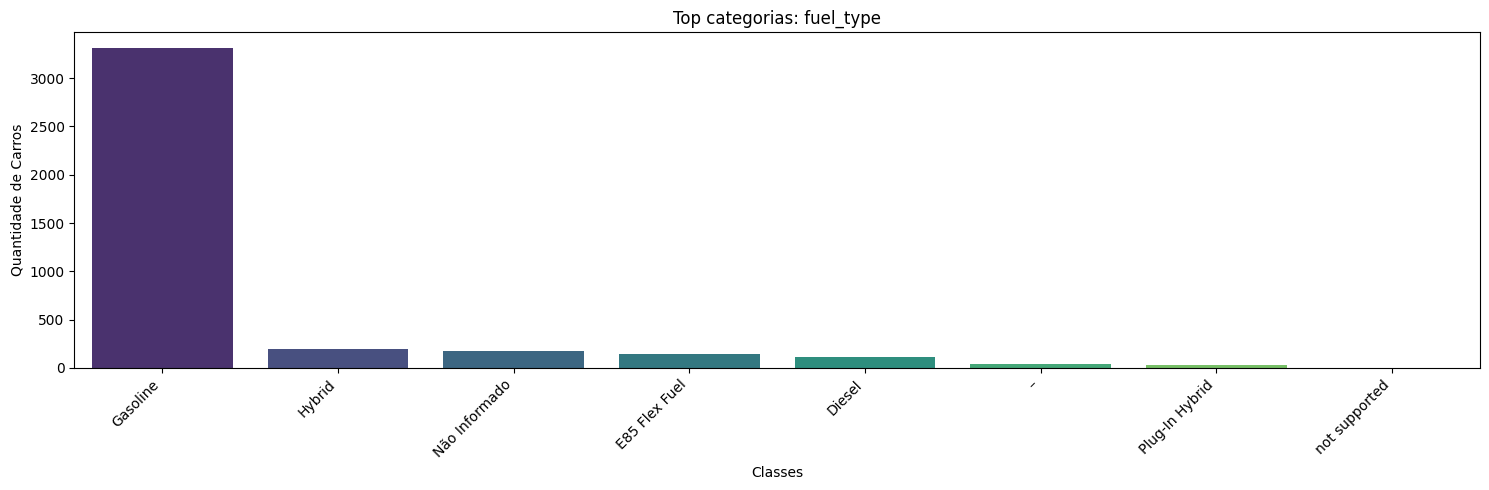

In [477]:
# Gráfico das categorias mais frequentes da variável fuel_type

grafico_distribuicao(df_cars, 'fuel_type')

O gráfico acima demonstra a grande predominância da classe 'Gasoline' nas ocorrências no atributo *fuel_type*, com 82,5% dos registros. Este fato indica a necessidade de tratamento desta variável, para que as classes menos frequentes possam contribuir e não apenas causar ruído ao modelo.

In [478]:
# Filtrando missings da coluna fuel_type

missings = df_cars[df_cars['fuel_type'].isnull()]

print(missings.head(10).to_string())

# Para fins de relatório exibimos apenas 10 registros,
# mas a análise qualitativa foi feita em cima do conjunto completo de 170 registros

        brand                    model  model_year   milage fuel_type                                       engine       transmission       ext_col   int_col       accident clean_title     price
9       Tesla  Model X Long Range Plus        2020  34000.0       NaN  534.0HP Electric Motor Electric Fuel System                A/T         Black     Black  None reported         Yes   69950.0
44      Lucid        Air Grand Touring        2022   3552.0       NaN  536.0HP Electric Motor Electric Fuel System        1-Speed A/T           Red     Beige  None reported         Yes  119999.0
68      Lucid        Air Grand Touring        2022   4900.0       NaN  536.0HP Electric Motor Electric Fuel System        1-Speed A/T           Red     Black  None reported         Yes   99000.0
92     Rivian    R1S Adventure Package        2023   2800.0       NaN  835.0HP Electric Motor Electric Fuel System        1-Speed A/T         White     Green  None reported         Yes   92000.0
122    Rivian    R1S Adve

Observando as instâncias em que o *fuel_type* aparece nulo, identificamos por meio da coluna *engine* que se tratam de modelos de carros elétricos.

A partir desta conclusão, justifica-se transformar os valores missing desta coluna em 'Electric', garantindo que esses veículos sejam classificados corretamente e contribuam para a performance do modelo.

Como esta é uma regra fixa, que não depende do estudo estatístico da base, podemos já fazer esta correção sem incorrer em problemas de data leakage.

In [479]:
# Transformando missing de fuel_type em 'Electric'

df_cars['fuel_type'] = df_cars['fuel_type'].fillna('Electric')

### Atributo *accident*:

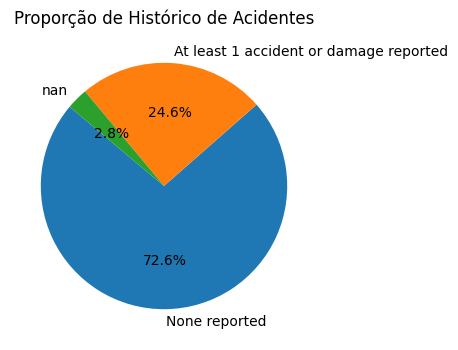

In [480]:
# Gráfico de pizza das categorias da variável accident

# Conta as frequências da coluna accident
dados_accident = df_cars['accident'].value_counts(dropna=False)

# Cria a moldura do gráfico
plt.figure(figsize=(4, 4))

# Cria o gráfico de pizza
plt.pie(dados_accident,
        labels=dados_accident.index,
        autopct='%1.1f%%', #coloca a porcentagem com uma casa decimal dentro da fatia
        startangle=140)

# Adiciona título
plt.title('Proporção de Histórico de Acidentes')

# Exibe o gráfico
plt.show()

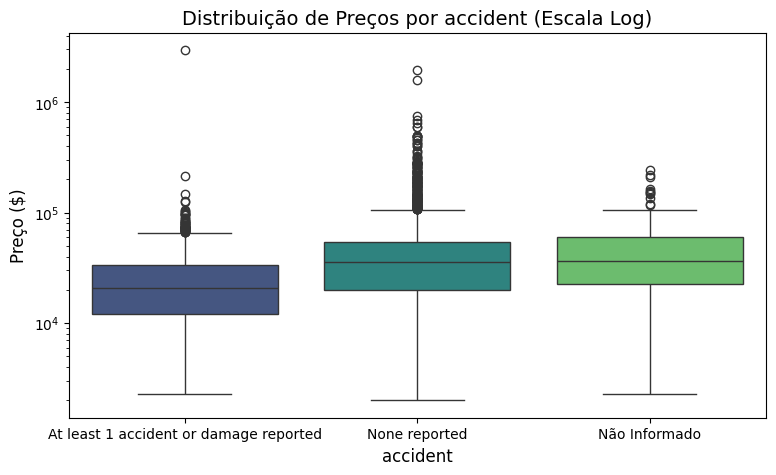

In [481]:
# Criando boxplot dos preços de veículos, nas classes da variável accident

boxplot_price(df_cars, 'accident')

In [482]:
# Calculando estatísticas descritivas de preço das classes de accident

# Calcula métricas por classe
resultado = df_cars.groupby('accident', dropna=False)['price'].agg(['mean', 'median', 'count','std','min','max'])

# Exibe o resultado
print(resultado.to_string())

                                                mean   median  count           std     min        max
accident                                                                                             
At least 1 accident or damage reported  28831.500000  20900.0    986  95401.765975  2300.0  2954083.0
None reported                           49638.073196  35667.5   2910  72554.118094  2000.0  1950995.0
NaN                                     50788.389381  36500.0    113  45260.414855  2300.0   244896.0


**Impacto de sinistros no preço de revenda:**

Os dados corroboram a hipótese de que o histórico de sinistros impacta negativamente o valor de revenda, uma vez que a mediana de preços de veículos sem acidentes registrados (35.667 USD) é aproximadamente 71% superior à de veículos com histórico de danos (20.900 USD).

Embora o desvio padrão elevado em ambos os grupos indique que outros fatores também influenciam o preço final, a queda consistente tanto na média quanto na mediana confirma que o registro de acidentes atua como detrator de valor no mercado de usados.

O boxplot reforça visualmente essa tendência de desvalorização: embora haja uma zona de intersecção entre os preços, nota-se um claro deslocamento vertical das caixas.

**Discussão dos registros nulos:**

Aproximadamente 73% do dataset apresenta o valor 'None reported' na coluna *accident*, sendo esta então a classe mais frequente.

Adicionalmente, observamos que a média e a mediana de preço para os valores nulos (NaN) estão muito próximas dos valores da classe 'None reported', enquanto a categoria com acidentes registrados apresenta um comportamento de preço nitidamente inferior e distinto.

Essas observações confirmam que os registros nulos (~3% da base) se comportam financeiramente como veículos sem acidentes, reforçando a decisão de preenchê-los com o valor 'None reported'.

In [483]:
# Transformando missings de accident em 'None reported'

df_cars['accident'] = df_cars['accident'].fillna('None reported')

### Atributo *clean_title*:

In [484]:
# Distribuição de frequencia da variável clean_title

analisar_distribuicao(df_cars, 'clean_title')

--- Análise da Variável: clean_title ---
Total de classes únicas (incluindo NaN): 2

             Frequência Absoluta  Frequência Relativa (%)
clean_title                                              
Yes                         3413                    85.13
NaN                          596                    14.87


O atributo *clean_title* apresenta apenas uma classe explícita 'Yes' e 596 valores nulos.

Partimos da hipótese de que essa estrutura por omissão indica a ausência de um título limpo. Para testar essa premissa, realizaremos a binarização do atributo, convertendo os valores nulos em 'No', e avaliaremos se a relação resultante com a variável alvo (price) é consistente com a lógica de negócio.

In [485]:
# Tranformando missings de clean_title em 'No'

df_cars['clean_title'] = df_cars['clean_title'].fillna('No')

In [486]:
# Analisando estatísticas descritivas de preço nos novos grupos

comparativo_precos = df_cars.groupby('clean_title')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)

                     mean   median  count           std     min        max
clean_title                                                               
No           60695.077181  42996.5    596  57982.778955  2300.0   449991.0
Yes          41734.390272  29000.0   3413  81472.770029  2000.0  2954083.0


A variável *clean_title* tem como função atestar a disponibilidade de um título sem pendências legais ou sinistros graves, um atributo que, teoricamente, deveria valorizar o veículo e oferecer maior segurança ao comprador. Com base nessa premissa, partimos da hipótese de que a binarização interpretativa (nulo = 'No') resultaria em uma mediana de preços inferior para o grupo sem a confirmação do título limpo.

Contudo, a análise estatística refutou essa expectativa: o grupo 'No' apresentou uma mediana de 42.996 USD, significativamente superior aos 29.000 USD do grupo 'Yes'. Esse comportamento contradiz a lógica de mercado e demonstra que não há uma interpretação semântica confiável para os 15% da base que não possuem essa informação preenchida.

Somado à inconsistência, o fato de o atributo apresentar baixa variância (com 85% da base concentrada em uma única classe) compromete sua força de predição. Sem uma justificativa lógica para o comportamento dos dados omissos e para evitar a introdução de ruídos no algoritmo, optou-se pelo descarte da variável *clean_title*.

### Conclusões da análise das variáveis categóricas:



* As variáveis ***brand, model, engine, transmission, ext_col e int_col*** apresentam uma granularidade excessiva. Esse comportamento exige que, na etapa de Pré-processamento, sejam aplicadas técnicas para reduzir o número de categorias, consolidando classes irrelevantes para evitar o overfitting do modelo.

* Em relação a variável ***fuel_type***, observou-se uma forte concentração de instâncias (82,5%) na categoria 'Gasoline'. Este desbalanceamento sugere que o modelo terá dificuldade em aprender o comportamento de preços para combustíveis alternativos. Para mitigar esse efeito, buscaremos consolidar as classes minoritárias de forma a melhorar sua representatividade. Adicionalmente concluiu-se que os valores nulos desta coluna devem ser classificados como veículos 'Electric'.

* A variável ***accident*** apresenta um comportamento consistente com o esperado, ou seja, a maioria dos veículos anunciados (~75%) não possui histórico de acidentes. Além disso, veículos com sinistro tendem a ter preços de mercado mais baixos, indicando que esta variável poderá ser um bom indicador para a depreciação do preço. Dada a maior frequência da classe 'None reported', os registros nulos foram incluídos nessa classe.

* Identificou-se que a coluna ***clean_title*** apresenta uma única classe explícita ("Yes"), enquanto as demais ocorrências constam como valores ausentes. Este comportamento poderia indicar que os campos nulos representam a ausência de um título limpo, mas essa hipótese foi refutada pelo teste de binarização interpretativa. Optaremos pelo descarte da variável.

Após o tratamento de cada atributo na etapa de feature engineering, discutiremos ainda a relação entre as novas categorias criadas e a variável target *price*.

## 4.3 Variáveis numéricas

### Estatísticas Descritivas

In [487]:
# Estatísticas descritivas dos atributos numéricos do dataset

df_cars.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


In [488]:
# Coeficiente de variação (desvio padrão / média)

# Seleciona colunas numéricas
numericas = df_cars.select_dtypes(include='number')

# Calcula o coeficiente (%)
cv = (numericas.std() / numericas.mean()) * 100
print(cv)


model_year      0.302891
milage         80.807445
price         176.666665
dtype: float64


1. As variáveis ***milage*** e ***price*** têm
média maior que a mediana, caracterizando assimetria à direita (Positiva). Este comportamento indica que estas colunas contêm valores extremos altos (possivelmente outliers), que puxam a média para cima.

    De fato podemos notar, por exemplo, que o carro mais caro da base custa quase 3 milhões de dólares, enquanto a mediana está na casa dos 31 mil dólares.

2. Já a variável ***model_year*** tem o comportamento inverso (assimetria à esquerda), indicando valores extremos mais baixos.

    Este comportamento é realmente o esperado. Dado que a base data de 2023, a maior parte dos carros anunciados foram fabricados próximo a essa época, com uma minoria de carros bastante antigos (sendo o mais antigo de 1974).

3. Analisando o coeficiente de variação, podemos afirmar que a variável *model_year* é uma variável bastante homogênea, ou seja, seu range de valores está bastante próximo da média. Já *milage* e *price* têm coeficiente de dispersão bastante alto, indicando que provavelmente estas classes contém mais outliers e/ou outliers mais extremos.

### Gráficos Boxplot

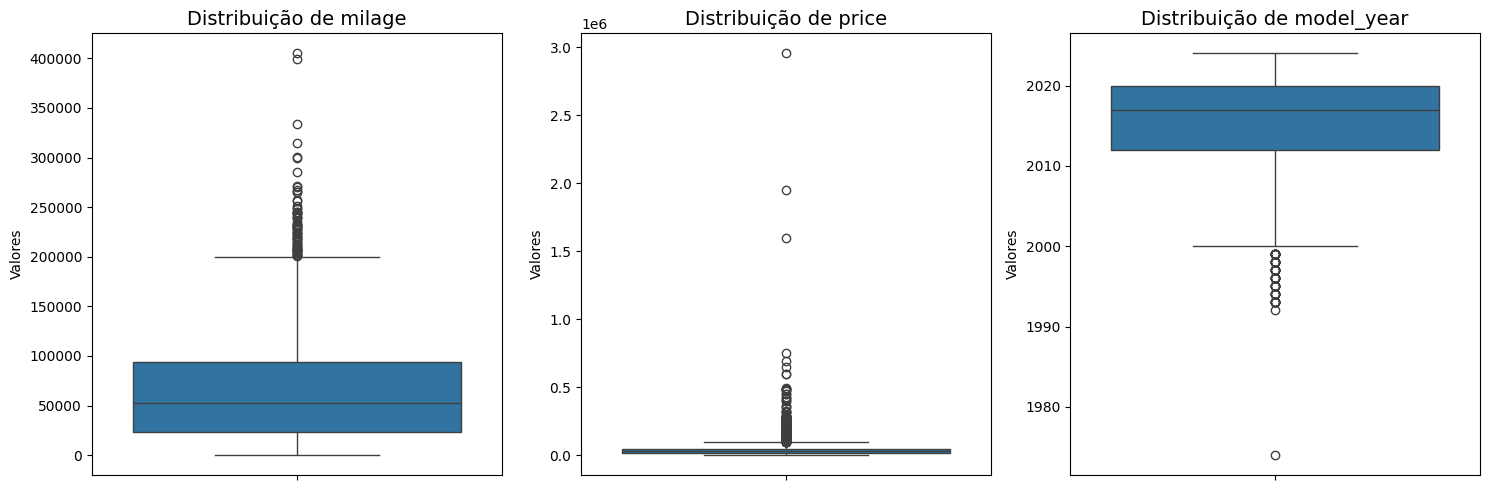

In [489]:
# Gráficos boxplot das variáveis numéricas do dataset: model_year, mileage e price

# Lista das variáveis numéricas
variaveis = ['milage', 'price', 'model_year']

# Cria uma moldura com 3 colunas para armazenar os 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Para cada variável, desenha o respectivo boxplot e coloca títulos
for i, var in enumerate(variaveis):
    sns.boxplot(y=df_cars[var], ax=axes[i])
    axes[i].set_title(f'Distribuição de {var}', fontsize=14)
    axes[i].set_ylabel('Valores')

# Exibe o gráfico
plt.tight_layout()
plt.show()

A análise visual através dos boxplots, apoiada pelas estatísticas descritivas, revela três comportamentos distintos:

**Preço (*price*)**: É a variável com a maior dispersão e presença de valores extremos. Enquanto 75% da base custa até 49.990 USD, o valor máximo atinge impressionantes 2.95 milhões USD. Essa disparidade pode enviesar o modelo, fazendo-o priorizar os outliers e perder precisão no mercado comum. Portanto, será necessário avaliar estratégias para lidar com essa variabilidade, garantindo que os valores extremos não prejudiquem a performance da regressão.

**Quilometragem (*milage*)**: Apresenta uma distribuição mais equilibrada, porém com uma cauda longa. A maioria dos veículos (IQR) situa-se entre 23 mil e 94 mil milhas. Veículos que ultrapassam o limite superior do boxplot (aproximadamente 200 mil milhas) são considerados outliers de uso, chegando ao máximo de 405 mil milhas, refletindo veículos de frota ou de vida útil avançada.

**Ano do Modelo (*model_year*)**: O gráfico mostra uma concentração em veículos recentes, com 50% da base fabricada entre 2012 e 2020. Os outliers aqui são os veículos "vintage" ou antigos: qualquer carro fabricado antes de 2000 é uma exceção estatística, representando uma parcela mínima da base que foge do comportamento de mercado dos seminovos.

### Análise de correlação

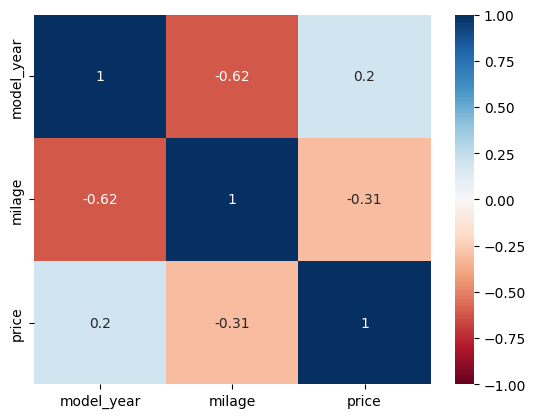

In [490]:
# Heatmap da correlação de Pearson entre variáveis numéricas

sns.heatmap(df_cars.select_dtypes(include='number').corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1);

A análise da matriz de correlação de Pearson revela que não existem associações lineares fortes entre as variáveis numéricas do dataset. A relação mais expressiva ocorre entre *model_year* e *milage* (-0,62), indicando uma correlação negativa moderada, onde veículos mais recentes tendem a apresentar menor quilometragem, conforme esperado.

Entretanto, as correlações envolvendo a variável alvo *price* são fracas sugerindo que o preço não é determinado de forma isolada por nenhum desses fatores de maneira linear.

Esses resultados indicam que o preço dos automóveis é um fenômeno multivariado e complexo, onde atributos categóricos de alta cardinalidade — como marca e modelo — podem exercer maior influência do que as variáveis numéricas isoladas.

### Conclusões da análise das variáveis numéricas:

* A variável target ***price*** não apresenta uma distribuição simétrica, demonstrando uma forte assimetria à direita. O estudo da variável indicou que a maior parte da base concentra-se em uma faixa de preço padrão, mas é afetada por uma cauda longa de veículos de superluxo. Sem o devido tratamento, esses valores extremos (outliers) podem enviesar as estimativas, prejudicando a precisão do modelo no mercado comum.

* As variáveis ***milage*** e ***model_year***, apesar de em menor grau que *price*, também apresentam distribuições assimétricas com a presença de outliers em suas extremidades (uso severo e veículos antigos, respectivamente), o que exigirá estratégias de tratamento.

* Há uma evidente disparidade na ordem de grandeza das variáveis: *model_year* varia em unidades de milhares, *milage* em centenas de milhares e *price* atinge a casa dos milhões. Esta característica evidencia a necessidade de normalização das escalas, garantindo que modelos lineares ou baseados em distância não atribuam pesos desproporcionais aos atributos de maior magnitude numérica.

# 5. Pré-processamento: Feature Engineering

Nesta etapa, transformaremos os dados brutos em formatos que otimizem o aprendizado do modelo. Identificamos que as variáveis *brand, engine, transmission, ext_col* e *int_col* apresentam uma granularidade excessiva (alta cardinalidade). Esse comportamento exige a aplicação de técnicas para reduzir o número de categorias, consolidando classes com baixa representatividade para evitar o overfitting e garantir que o modelo aprenda padrões gerais em vez de decorar ruídos.

A variável *model* por sua vez apresenta o mesmo desafio. No entanto, a estratégia utilizada para seu tratamento será o target encoding. Como esta técnica depende do conhecimento estatístico do dataset, poderá ser aplicada apenas após o split da base.

Como comentado anteriormente, a variável *fuel_type* apresenta um forte desbalanceamento, com 86% das instâncias concentradas na categoria 'Gasoline'. Esse cenário sugere que o algoritmo terá dificuldade em prever preços para veículos com combustíveis alternativos. Para mitigar esse efeito e melhorar a performance preditiva, buscaremos agrupar as classes minoritárias, melhorando a representatividade desses grupos.

É importante notar que, para evitar data leakage, neste capítulo realizaremos apenas transformações com regras fixas. Outros tipos de transformação poderão ser aplicadas após a divisão do dataset entre treino e teste.

**Nota:** Para fins de relatório, exibimos apenas as 50 classes mais frequentes de cada variável. Contudo, todas as categorias foram integralmente consideradas para o planejamento e execução do tratamento de cada atributo.

## Marca (*brand*)

In [491]:
# Distribuição de frequencia da variável brand

analisar_distribuicao(df_cars, 'brand')

--- Análise da Variável: brand ---
Total de classes únicas (incluindo NaN): 57

               Frequência Absoluta  Frequência Relativa (%)
brand                                                      
Ford                           386                     9.63
BMW                            375                     9.35
Mercedes-Benz                  315                     7.86
Chevrolet                      292                     7.28
Porsche                        201                     5.01
Audi                           200                     4.99
Toyota                         199                     4.96
Lexus                          163                     4.07
Jeep                           143                     3.57
Land                           130                     3.24
Nissan                         116                     2.89
Cadillac                       107                     2.67
GMC                             91                     2.27
RAM                 

Para otimizar a performance do modelo de regressão e mitigar o problema da alta cardinalidade (57 marcas para 4.009 registros), consolidaremos a variável *brand* em três categorias estratégicas. Esta segmentação baseia-se no conhecimento de domínio do mercado automobilístico, agrupando fabricantes pelo seu posicionamento de preço, prestígio e proposta de valor.

As novas *brand_tiers* são definidas da seguinte forma:

**Luxury & Exotic**: Composta por marcas de nicho, supercarros e alto luxo (ex: Ferrari, Porsche, Lamborghini). Representa veículos com baixa depreciação e preços regidos por exclusividade e performance de ponta.

**Premium**: Inclui marcas de luxo consolidadas e modelos executivos (ex: BMW, Mercedes-Benz, Tesla, Audi). Representa o segmento de alto valor agregado e tecnologia superior, mas com maior volume de mercado que a categoria anterior.

**Mainstream & Others**: Agrupa marcas de volume e fabricantes generalistas (ex: Toyota, Ford, Chevrolet, Honda). Representa o mercado de massa, focado em utilidade e escala, onde os preços tendem a ser mais sensíveis à depreciação e quilometragem.

In [492]:
# Criando tiers de marcas, baseados em conhecimento de negócio

brand_tiers = {
    # LUXURY & EXOTIC
    'Porsche': 'Luxury_Exotic', 'Lamborghini': 'Luxury_Exotic', 'Ferrari': 'Luxury_Exotic',
    'Rolls-Royce': 'Luxury_Exotic', 'Aston': 'Luxury_Exotic', 'Bentley': 'Luxury_Exotic',
    'McLaren': 'Luxury_Exotic', 'Bugatti': 'Luxury_Exotic', 'Lotus': 'Luxury_Exotic',
    'Maybach': 'Luxury_Exotic', 'Maserati': 'Luxury_Exotic', 'Lucid': 'Luxury_Exotic',
    'Rivian': 'Luxury_Exotic', 'Land': 'Luxury_Exotic',

    # PREMIUM
    'BMW': 'Premium', 'Mercedes-Benz': 'Premium', 'Audi': 'Premium',
    'Lexus': 'Premium', 'Tesla': 'Premium', 'Cadillac': 'Premium',
    'Jaguar': 'Premium', 'Genesis': 'Premium', 'Alfa': 'Premium',
    'Volvo': 'Premium', 'INFINITI': 'Premium', 'Acura': 'Premium',
    'Lincoln': 'Premium', 'Polestar': 'Premium', 'Karma': 'Premium',

    # MAINSTREAM & OTHERS
    'Ford': 'Mainstream', 'Chevrolet': 'Mainstream', 'Toyota': 'Mainstream',
    'Jeep': 'Mainstream', 'Nissan': 'Mainstream', 'RAM': 'Mainstream',
    'GMC': 'Mainstream', 'Dodge': 'Mainstream', 'Kia': 'Mainstream',
    'Hyundai': 'Mainstream', 'Subaru': 'Mainstream', 'Mazda': 'Mainstream',
    'Honda': 'Mainstream', 'Volkswagen': 'Mainstream', 'Chrysler': 'Mainstream',
    'Buick': 'Mainstream', 'MINI': 'Mainstream', 'Mitsubishi': 'Mainstream',
    'Pontiac': 'Mainstream', 'Hummer': 'Mainstream', 'Scion': 'Mainstream',
    'Saturn': 'Mainstream', 'FIAT': 'Mainstream', 'Mercury': 'Mainstream',
    'Saab': 'Mainstream', 'Suzuki': 'Mainstream', 'smart': 'Mainstream',
    'Plymouth': 'Mainstream'
}

# Criando a nova feature
df_cars['brand_tier'] = df_cars['brand'].map(brand_tiers).fillna('Mainstream')

# Verifica estatísticas dos novos grupos
comparativo_precos = df_cars.groupby('brand_tier')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)



                        mean   median  count            std     min        max
brand_tier                                                                    
Luxury_Exotic  113580.295082  67997.5    488  197473.376275  5750.0  2954083.0
Mainstream      30447.236308  26500.0   1972   25066.177892  2300.0   489995.0
Premium         40764.755326  32000.0   1549   34680.915463  2000.0   479995.0


In [493]:
# Distribuição de frequencia da variável brand_tier

analisar_distribuicao(df_cars, 'brand_tier')

--- Análise da Variável: brand_tier ---
Total de classes únicas (incluindo NaN): 3

               Frequência Absoluta  Frequência Relativa (%)
brand_tier                                                 
Mainstream                    1972                    49.19
Premium                       1549                    38.64
Luxury_Exotic                  488                    12.17


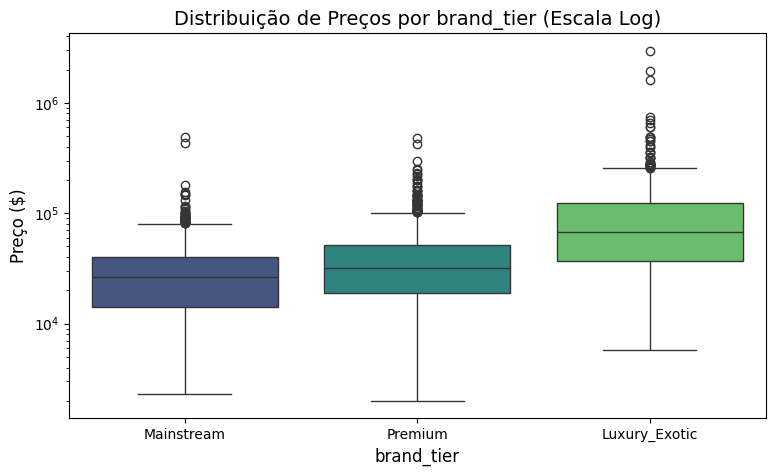

In [494]:
# Criando boxplot dos preços de veículos, nas classes da variável brand_tier

boxplot_price(df_cars, 'brand_tier')

O boxplot ratifica a eficácia da segmentação: o grupo **Luxury & Exotic** apresenta a maior mediana e os valores mais elevados, confirmando o prêmio por exclusividade e performance. O tier **Premium** demonstra um patamar de preço superior a mediana geral, com dispersão moderada, enquanto o **Mainstream & Others** concentra a maior volumetria com a menor mediana, refletindo o mercado de massa. Essa distinção de patamares financeiros valida o uso dos tiers como preditores para o modelo.

## Tipo de combustível (*fuel_type*)

In [495]:
# Distribuição de frequencia da variável fuel_type

analisar_distribuicao(df_cars, 'fuel_type')

--- Análise da Variável: fuel_type ---
Total de classes únicas (incluindo NaN): 8

                Frequência Absoluta  Frequência Relativa (%)
fuel_type                                                   
Gasoline                       3309                    82.54
Hybrid                          194                     4.84
Electric                        170                     4.24
E85 Flex Fuel                   139                     3.47
Diesel                          116                     2.89
–                                45                     1.12
Plug-In Hybrid                   34                     0.85
not supported                     2                     0.05


In [496]:
# Imprimindo registros de fuel_type 'not supported'

df_cars[df_cars['fuel_type'] == 'not supported']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_tier
2894,Toyota,Mirai Limited,2021,44000.0,not supported,182.0HP Electric Motor Hydrogen Fuel,A/T,Gray,Black,None reported,Yes,18500.0,Mainstream
3700,Toyota,Mirai Base,2016,40000.0,not supported,151.0HP Electric Motor Hydrogen Fuel,A/T,Silver,Black,None reported,Yes,9500.0,Mainstream


Podemos perceber que os registros de *fuel_type* 'not supported' se referem, na verdade, a carros elétricos (observe coluna *engine*). Logo, podemos assumir que o *fuel_type* desses registros equivale a categoria 'Electric' criada anteriormente.

In [497]:
# Imprimindo registros de fuel_type '–'

df_cars[df_cars['fuel_type'] == '–'].head(10)

# Para fins de relatório exibimos apenas 10 registros,
# mas a análise qualitativa foi feita em cima do conjunto completo de registros '-'

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_tier
130,Chrysler,Pacifica Touring,2017,87305.0,–,–,9-Speed A/T,Silver,Black,None reported,Yes,9000.0,Mainstream
257,Toyota,Land Cruiser Base,1993,231500.0,–,–,A/T,White,Gray,None reported,Yes,29500.0,Mainstream
338,Mazda,Mazda3 s Grand Touring,2016,85000.0,–,–,A/T,Black,Black,At least 1 accident or damage reported,Yes,18500.0,Mainstream
491,Chrysler,Pacifica Touring,2017,63000.0,–,–,9-Speed A/T,White,Beige,None reported,Yes,20000.0,Mainstream
692,Honda,Civic EX,1993,58981.0,–,–,A/T,White,Beige,None reported,Yes,9599.0,Mainstream
855,Ford,Bronco,1974,6217.0,–,–,–,Dark Gray Metallic,–,None reported,Yes,115000.0,Mainstream
923,Dodge,Challenger R/T,2010,100100.0,–,–,Transmission w/Dual Shift Mode,Purple,Black,None reported,Yes,17000.0,Mainstream
995,Dodge,Challenger R/T Scat Pack,2019,43000.0,–,–,6-Speed M/T,Green,Black,None reported,Yes,50000.0,Mainstream
1063,Mazda,Mazda6 i Grand Touring,2016,83100.0,–,–,A/T,White,White,None reported,Yes,17800.0,Mainstream
1083,Dodge,Challenger R/T,2010,73000.0,–,–,A/T,Black,Black,None reported,Yes,17500.0,Mainstream


Para o tratamento de dados omissos ('-') na variável *fuel_type*, vamos optar pela imputação do valor 'Gasoline'. Esta decisão fundamenta-se em duas premissas:

* A análise qualitativa dos registros afetados revelou veículos vintage/antigos e modelos de alta performance (ex: Dodge Challenger), que utilizam predominantemente este combustível.

* Dado que a categoria 'Gasoline' já representa 86% da base, a inclusão desses registros não altera a distribuição da moda e evita a criação de subcategorias com baixa significância estatística.

A potencial distorção de preços causada por veículos de luxo ou colecionáveis dentro desta classe será mitigada pela criação da coluna de segmentos e marcas, que isolará o efeito do valor desses modelos da variável de combustível.

In [498]:
# Criação de nova coluna tratada fuel_group, com dados agrupados de fuel_type

# Transforma '-' em Gasoline
df_cars['fuel_type'] = df_cars['fuel_type'].replace('–', 'Gasoline')

# Define os novos grupos
mapeamento_combustivel = {
    'Gasoline': 'Gasoline',
    'Hybrid': 'Green Energy',
    'Plug-In Hybrid': 'Green Energy',
    'Electric': 'Green Energy',
    'not supported': 'Green Energy',
    'Diesel': 'Other Combustion',
    'E85 Flex Fuel': 'Other Combustion'
}

# Aplica agrupamento
df_cars['fuel_group'] = df_cars['fuel_type'].map(mapeamento_combustivel)

# Verifica estatísticas dos novos grupos
comparativo_precos = df_cars.groupby('fuel_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos.to_string())

                          mean   median  count           std     min        max
fuel_group                                                                     
Gasoline          44420.556649  29799.0   3354  85107.627145  2000.0  2954083.0
Green Energy      52042.730000  46500.0    400  29301.740742  4200.0   175000.0
Other Combustion  34549.415686  28999.0    255  24592.215241  4500.0   200000.0


Para otimizar o aprendizado do modelo e reduzir o ruído, a variável *fuel_type* foi reestruturada em três novas classes que refletem as divisões de mercado:

**Gasoline:** Categoria majoritária que engloba veículos convencionais e
modelos de performance/clássicos. Representa o padrão de consumo tradicional.

**Green Energy:** Consolida veículos elétricos e híbridos (incluindo plug-ins). Esta classe agrupa tecnologias de baixa emissão, que possuem curvas de depreciação e incentivos fiscais distintos dos modelos a combustão.

**Other Combustion:** Reúne alternativas como Diesel e Flex Fuel. São nichos específicos, como utilitários pesados ou motores adaptáveis.

Essa consolidação mitiga o problema do desbalanceamento, contribuindo para que o modelo tenha amostras suficientes para identificar padrões.

In [499]:
# Distribuição de frequencia da variável fuel_group

analisar_distribuicao(df_cars, 'fuel_group')

--- Análise da Variável: fuel_group ---
Total de classes únicas (incluindo NaN): 3

                  Frequência Absoluta  Frequência Relativa (%)
fuel_group                                                    
Gasoline                         3354                    83.66
Green Energy                      400                     9.98
Other Combustion                  255                     6.36


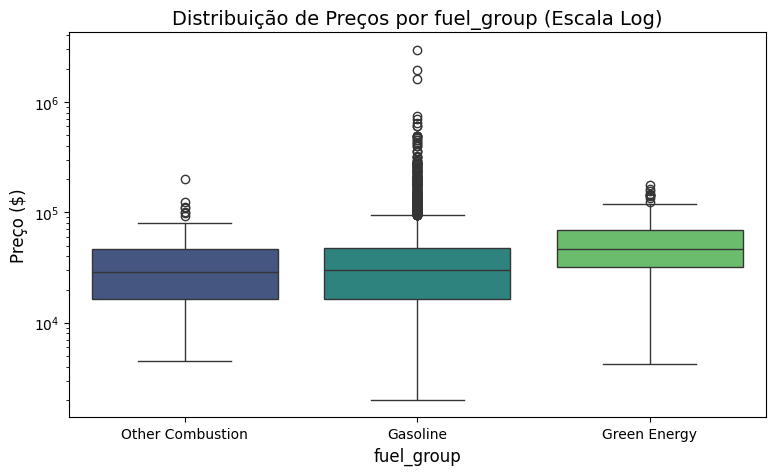

In [500]:
# Criando boxplot dos preços de veículos, nas classes da variável fuel_group

boxplot_price(df_cars, 'fuel_group')

O boxplot confirma a distinção de mercado entre os grupos: **Green Energy** apresenta a maior mediana de preços, refletindo o custo de novas tecnologias, enquanto **Gasoline** exibe a maior dispersão devido à presença de modelos de luxo e clássicos. Já o grupo **Other Combustion** é similar a Gasoline em termos de mediana, mas menos disperso. Essa distinção de comportamento valida a reestruturação da variável.

## Motor (*engine*)

In [501]:
# Distribuição de frequencia da variável engine

analisar_distribuicao(df_cars, 'engine')

--- Análise da Variável: engine ---
Total de classes únicas (incluindo NaN): 1146

                                                                       Frequência Absoluta  Frequência Relativa (%)
engine                                                                                                             
2.0L I4 16V GDI DOHC Turbo                                                              52                     1.30
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel                                            48                     1.20
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel                                            47                     1.17
–                                                                                       45                     1.12
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel                                   44                     1.10
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel                                            42               

A coluna original *engine* apresenta uma alta cardinalidade (1.146 variações de texto), o que dificultaria o aprendizado do modelo. Para resolver isso, vamos aplicar uma técnica de Extração de Atributos, transformando uma única coluna de texto em quatro variáveis estruturadas que explicam a variação de preços sob uma perspectiva técnica e comercial:

**Configuração do Motor (*engine_config* - Categórica)**: Consolidamos as diferentes arquiteturas de cilindros (como V6, V8 ou motores em linha). Para o modelo, isso funciona como um indicador de categoria: motores com mais cilindros geralmente equipam veículos de luxo ou alto desempenho, ou seja, indicam um preço mais elevado.

**Potência (*engine_hp* - Numérica)**: Extraímos a cavalaria (Horsepower) como um valor contínuo. Esta é a variável que tende a ter maior correlação com o valor de venda: ela é o principal argumento de mercado para justificar por que um carro custa mais caro que outro, dentro da mesma categoria.

**Cilindrada/Litragem do Motor (*engine_displacement* - Numérica)**: Isolamos o tamanho físico do motor (ex: 2.0, 5.7). No contexto de negócio, essa variável ajuda o modelo a entender o porte do veículo: motores maiores são típicos de utilitários e SUVs robustos, que mantêm valores de revenda mais altos devido à sua capacidade de trabalho.

**Presença de Turbo (*is_turbo* - Binária)**: Criamos uma marcação (0 ou 1) para motores com tecnologia Turbo ou Supercharged. Esta variável é um ajuste de precisão: ela explica ao modelo por que um motor pequeno pode ser mais caro que um motor grande.

### Configuração do motor (*engine_config*)

In [502]:
# Criando a coluna engine_config

# Cria uma coluna engine_std removendo hifens e espaços
df_cars['engine_std'] = df_cars['engine'].str.lower().str.replace(r'[- ]', '', regex=True)

# Estabelece os padrões que indicam a configuração do motor
# [vwih]\d+ -> Buscas letras v, i, h, w seguidas de números, exemplos: v8, h6, i4, v612
# \d+cylinder -> Busca um (ou mais) número(s) seguido da palavra cylinder
# rotary|electric|ev|dualmotor|120ah -> Busca estes termos em específico
pure_pattern = r'([vihw]\d+|\d+cylinder|electric|ev|dualmotor|120ah|rotary)'

# Extrai informação da configuração para nova coluna
df_cars['engine_config'] = df_cars['engine_std'].str.extract(pure_pattern, expand=False)

# Verifica estatísticas dos novos grupos
extracao_bruta = df_cars.groupby('engine_config', dropna=False)['price'].agg(['mean', 'median', 'count','std'])
print(extracao_bruta.sort_values(by='count', ascending=False))

                       mean     median  count            std
engine_config                                               
8cylinder      4.640131e+04    34500.0   1007   99167.658060
v6             2.939509e+04    25500.0    899   21134.508819
4cylinder      2.247564e+04    19000.0    739   15651.347099
6cylinder      5.437402e+04    43000.0    338   45211.976975
NaN            5.217035e+04    42298.0    208   56079.958116
electric       5.402171e+04    46875.0    168   26928.999923
v624           4.438690e+04    39979.0    165   26510.831848
i416           3.520650e+04    29255.0    157   33073.338102
v816           5.744204e+04    46999.0     72   52896.363139
v832           1.211004e+05    96900.0     64   82916.410713
12cylinder     1.402592e+05    81330.0     37  142755.434199
10cylinder     1.665301e+05   100000.0     23  330753.535864
5cylinder      1.858440e+04    10149.5     20   21073.039629
i312           2.793440e+04    28979.0     15    4090.068630
3cylinder      4.528069e

De todas as variações encontradas originalmente, podemos refinar os dados agrupando termos que possuem o mesmo significado técnico ou posicionamentos de mercado equivalentes. Esta etapa reduz a complexidade do modelo ao consolidar os registros nas seguintes 5 classes:

**Entry_Standard (3 e 4 cilindros)**: Representa o motor de entrada do mercado. É o segmento focado em economia de combustível e alto volume de vendas.

**Mid_Performance (5 e 6 cilindros)**: Identifica veículos com maior potência e, consequentemente, maior valor agregado e prestígio.

**High_V8 (8 cilindros)**: Define o padrão de força (comum em caminhonetes e utilitários) e a performance superior típica de modelos de alto desempenho.

**Exotic (10 e 12 cilindros)**: Ocupa o topo da pirâmide do mercado, onde o preço é regido pela exclusividade e pela engenharia de luxo.

**Electric**: Categoria dedicada exclusivamente à tecnologia de propulsão elétrica, que possui uma lógica de valor e mercado distinta dos modelos a combustão.

**Sem Informação:** Quando não houver informação explícita sobre a configuração do motor.

In [503]:
# Agrupando configuraçãoes engine_config em classes que fazem sentido de mercado

# Dicionário que define a classe final de cada configuração encontrada
engine_mapping = {
    # Entry_Standard (3 e 4 cilindros)
    '3cylinder': 'Entry_Standard', 'i3': 'Entry_Standard', 'i312': 'Entry_Standard',
    '4cylinder': 'Entry_Standard', 'i4': 'Entry_Standard', 'i416': 'Entry_Standard',
    'i42': 'Entry_Standard', 'h4': 'Entry_Standard', 'h416': 'Entry_Standard',

    # Mid_Performance (5 e 6 cilindros)
    '5cylinder': 'Mid_Performance', 'i5': 'Mid_Performance',
    '6cylinder': 'Mid_Performance', 'v6': 'Mid_Performance', 'v612': 'Mid_Performance',
    'v618': 'Mid_Performance', 'v624': 'Mid_Performance', 'i6': 'Mid_Performance',
    'i624': 'Mid_Performance', 'h6': 'Mid_Performance', 'h624': 'Mid_Performance',

    # High_V8 (8 cilindros)
    '8cylinder': 'High_V8', 'v8': 'High_V8', 'v816': 'High_V8',
    'v832': 'High_V8', 'v86': 'High_V8',

    # Exotic
    '10cylinder': 'Exotic', 'v10': 'Exotic', 'v1040': 'Exotic',
    '12cylinder': 'Exotic', 'v12': 'Exotic', 'v1248': 'Exotic',
    'w12': 'Exotic', 'w1248': 'Exotic', 'w1664': 'Exotic',
    'rotary': 'Exotic',

    # Electric
    'electric': 'Electric', 'ev': 'Electric', 'dualmotor': 'Electric', '120ah': 'Electric'
}
# Aplica dicionário na coluna orginal engine_config
df_cars['engine_config'] = df_cars['engine_config'].map(engine_mapping)

# Preenche os registros nulos com 'Sem Informação'
df_cars['engine_config'] = df_cars['engine_config'].fillna('Sem Informação')

# Verifica estatísticas dos novos grupos
resumo = df_cars.groupby('engine_config')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(resumo.to_string())

                          mean    median  count            std     min        max
engine_config                                                                    
Electric          53602.531792   46598.0    173   26690.556783  4200.0   146000.0
Entry_Standard    25121.591489   22000.0    940   20435.754511  2300.0   299000.0
Exotic           216784.179775  129000.0     89  293206.285296  6800.0  1950995.0
High_V8           51805.856522   37900.0   1150   97753.639450  2000.0  2954083.0
Mid_Performance   38650.273292   30500.0   1449   37054.891506  2300.0   489000.0
Sem Informação    52170.350962   42298.0    208   56079.958116  2500.0   599995.0


In [504]:
# Distribuição de frequencia da variável engine_config

analisar_distribuicao(df_cars, 'engine_config')

--- Análise da Variável: engine_config ---
Total de classes únicas (incluindo NaN): 6

                 Frequência Absoluta  Frequência Relativa (%)
engine_config                                                
Mid_Performance                 1449                    36.14
High_V8                         1150                    28.69
Entry_Standard                   940                    23.45
Sem Informação                   208                     5.19
Electric                         173                     4.32
Exotic                            89                     2.22


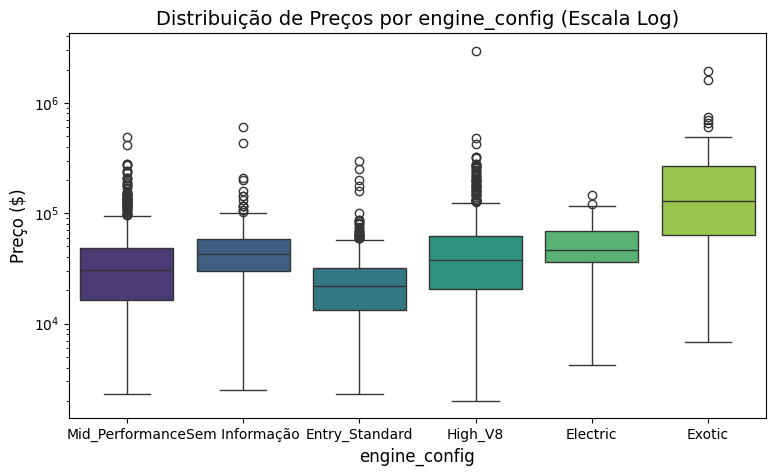

In [505]:
# Criando boxplot dos preços de veículos, nas classes da variável engine_config

boxplot_price(df_cars, 'engine_config')

O boxplot reflete uma hierarquia de preços entre as novas categorias de motorização, validando a estratégia:

A classe **Entry_Standard** apresenta a menor mediana (22k USD), confirmando seu papel como base do mercado. Já a **Mid_Performance** mostra um degrau claro de valor (mediana de 30,5k USD), consolidando veículos com maior valor agregado. Curiosamente são os motores mais comuns no mercado em estudo (36% das entradas do dataset).

As classes **High_V8** e **Electric** apresentam comportamentos de preço superiores, com medianas na faixa de 38k USD a 46k USD, indicando uma base de preços mais alta devido à tecnologia.

Como esperado, a classe **Exotic** é um outlier por natureza, com frequência de apenas 2%. Com a maior mediana do dataset (129k USD) e uma média ainda mais alta, ela isola os veículos de luxo extremo e alta cilindrada, contribuindo para que esse perfil não afete o aprendizado do modelo nos segmentos de volume.

Esta separação visual no boxplot é um excelente sinal para o modelo de Machine Learning, pois indica que a variável *engine_config* agora possui poder discriminatório sobre o preço.

### Potência (*engine_hp*)

In [506]:
# Criando a coluna engine_hp numérica

# Coloca todas as strings em letra minúscula
df_cars['engine_std'] = df_cars['engine'].str.lower() # Refaz a string auxiliar, porque dessa vez não quremos retirar hifen e espaço

# Estabelece os padrões que indicam o horsepower
# Busca números com ou sem casas decimais seguidos por hp
regex_pattern = r'(\d+\.?\d*)\s?hp'

# Extrai informação do hp para nova coluna
df_cars['engine_hp'] = df_cars['engine_std'].str.extract(regex_pattern, expand=False).astype(float)

print(f"Sucesso: {df_cars['engine_hp'].notnull().sum()} linhas")

Sucesso: 3201 linhas


In [507]:
# Estatísticas descritivas da variável engine_hp, em cada classe de engine_config

df_cars.groupby('engine_config')['engine_hp'].agg(['mean', 'median', 'count', 'std', 'min', 'max'])

,mean,median,count,std,min,max
engine_config,,,,,,
Electric,460.424460,425.0,139,209.693806,107.0,1020.0
Entry_Standard,211.823138,206.0,752,56.705226,70.0,455.0
Exotic,530.500000,552.0,62,121.454943,212.0,788.0
High_V8,413.815553,402.0,1003,96.050765,180.0,808.0
Mid_Performance,314.983936,304.0,1245,72.470848,140.0,640.0
Sem Informação,NaN,NaN,0,NaN,NaN,NaN


In [508]:
# Definindo função que cria gráfico boxplot de determinada variável numérica, para as classes de configuração do motor

def boxplot_engine_config (df, variavel_numerica):
    # Cria espaço para o gráfico
    plt.figure(figsize=(9, 5))

    # Cria o gráfico Boxplot
    sns.boxplot(x='engine_config', y=variavel_numerica, data=df,
                palette='viridis',
                order = ['Entry_Standard','Mid_Performance','High_V8','Exotic','Electric','Sem Informação'],
                hue='engine_config',
                legend=False)

    # Ajusta a escala
    plt.yscale('log') # Escala logarítmica para lidar com outliers extremos

    # Inclui os títulos
    plt.title(f'Distribuição de {variavel_numerica} por Configuração de motor (Escala Log)', fontsize=14)
    plt.xlabel('engine_config', fontsize=12)
    plt.ylabel(f'{variavel_numerica}', fontsize=12)


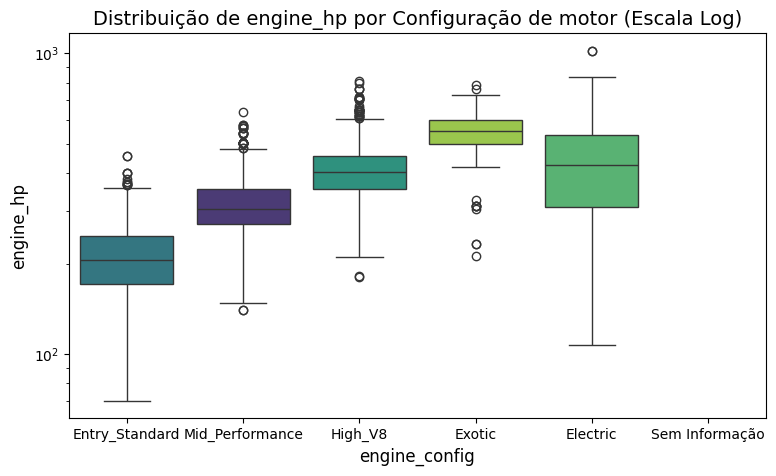

In [509]:
# Desenhando o boxplot de engine_hp, nas classes de engine_config

boxplot_engine_config(df_cars, 'engine_hp')

O Boxplot revela o comportamento de potência dentro de cada configuração de motor, permitindo as seguintes observações principais:

* Existe uma progressão clara e esperada das medianas. O grupo **Entry_Standard** apresenta o menor patamar de potência, seguido por **Mid_Performance**, **High_V8** e **Exotic**, validando a consistência da classificação de motores e respectiva potência.

* O grupo **Electric** destaca-se por possuir o maior Intervalo Interquartil (IQR) e o maior desvio padrão (209.7). Isso indica uma alta dispersão, uma vez que a categoria abriga desde veículos urbanos de baixa potência até superesportivos de alta performance.

* A proximidade entre média e mediana na maioria dos grupos indica distribuições relativamente simétricas, com poucos valores extremos fugindo do comportamento padrão de cada arquitetura de motor.

* Os valores mínimos e máximos de potência (hp) por categoria mostram-se tecnicamente condizentes com a realidade do mercado automobilístico, não demandando tratamentos específicos para outliers.

**Tratamento de dados ausentes em *engine_hp*:**
A extração via RegEx obteve sucesso em 80% da base (3.201 registros). Para os 20% remanescentes (808 registros), aplicaremos a estratégia de imputação por mediana agrupada:

O preenchimento será realizado com base na mediana de hp de cada categoria da coluna ***engine_config***. O uso da mediana, em vez da média, evita distorções causadas por outliers.

Nos registros sem configuração de motor identificada, utilizaremos a mediana global da base como salvaguarda.

Para evitar problemas de data leakage, este tratamento será realizado após o split da base entre treino e teste.

### Cilindrada/Litragem do Motor (*engine_displacement*)



In [510]:
# Criando a coluna engine_displacement numérica

# A coluna df_cars['engine_std'] será usada novamente (letras minúsculas)

# Estabelece os padrões que indicam a litragem
# Busca números com ou sem casas decimais seguidos ou não por espaço e depois l ou liter
regex_displacement = r'(\d+\.?\d*)\s?(?:l|liter)'

# Extrai informação dos litros para nova coluna
df_cars['engine_displacement'] = df_cars['engine_std'].str.extract(regex_displacement, expand=False).astype(float)

print(f"Sucesso: {df_cars['engine_displacement'].notnull().sum()} linhas")

Sucesso: 3792 linhas


In [511]:
# Estatísticas descritivas da variável engine_displacement, em cada classe de engine_config

df_cars.groupby('engine_config')['engine_displacement'].agg(['mean', 'median', 'count', 'std', 'min', 'max'])

,mean,median,count,std,min,max
engine_config,,,,,,
Electric,1.281250,0.65,8,0.924252,0.65,3.0
Entry_Standard,2.065708,2.00,939,0.309473,1.00,3.8
Exotic,5.885227,6.00,88,1.173220,1.30,8.4
High_V8,5.280418,5.30,1149,0.820600,3.80,8.1
Mid_Performance,3.410781,3.50,1447,0.532272,2.50,6.7
Sem Informação,3.111801,3.00,161,1.112676,1.50,6.6


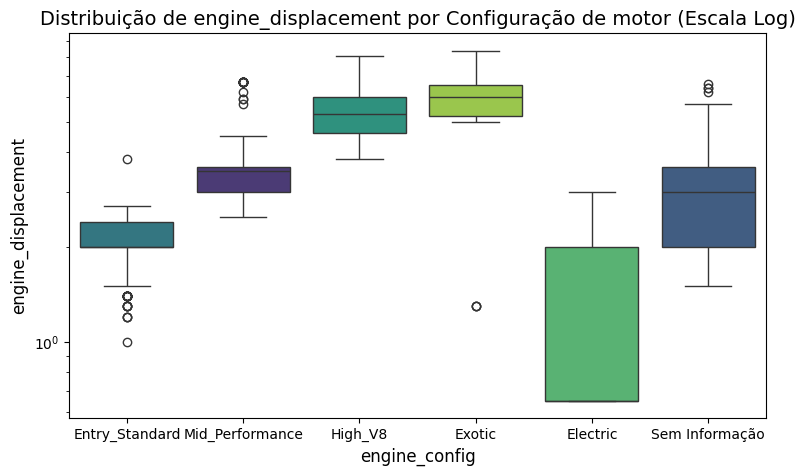

In [512]:
# Desenhando o boxplot de engine_displacement, nas classes de engine_config

boxplot_engine_config(df_cars, 'engine_displacement')

O Boxplot revela o comportamento da cilindrada dentro de cada configuração de motor, permitindo as seguintes observações:

* Observa-se uma progressão clara e coerente das medianas entre os motores a combustão. O grupo **Entry_Standard** apresenta o menor volume médio (2.0L), seguido por **Mid_Performance** (3.5L), **High_V8** (5.3L) e **Exotic** (6.0L), confirmando a precisão da categorização mecânica.

* O grupo **Exotic** apresenta a maior dispersão (maior desvio padrão, 1.17), refletindo a coexistência de tecnologias distintas, desde motores rotativos compactos até propulsores de alta litragem.

* A categoria **Electric** será posteriormente tratada, usando uma estratégia de imputação por domínio, que isola os veículos sem motor de combustão interna.

* A forte convergência entre média e mediana em todos os grupos indica distribuições bem comportadas e simétricas dentro de cada classe.

* Os valores mínimos e máximos de cilindrada por categoria mostram-se tecnicamente condizentes com a realidade do mercado automobilístico, não demandando tratamentos específicos para outliers.

**Tratamento de dados ausentes em *engine_displacement*:**
A extração via RegEx obteve sucesso em 95% da base (3.792 registros). Para os 5% remanescentes (217 registros), aplicaremos a estratégia de imputação por mediana agrupada:

O preenchimento será realizado com base na mediana de litragem de cada categoria da coluna ***engine_config***. O uso da mediana, em vez da média, evita distorções causadas por outliers.

Exceção da categoria ***Electric***: Nesta categoria, a informação de litragem não se aplica ao motor elétrico, ocorrendo apenas em casos particulares de híbridos ou extensores de autonomia. Por questões de consistência e conhecimento de domínio, adotaremos a estratégia de preencher toda esta categoria com *engine_displacement = 0.0*.

Para evitar problemas de data leakage, este tratamento será realizado após o split da base entre treino e teste.

### Presença de turbo (*is_turbo*)

In [513]:
# Criando uma coluna booleana para identificar turbo
df_cars['is_turbo'] = df_cars['engine_std'].str.contains(r'turbo|supercharge', na=False)

# Verificação da distribuição por categoria de motor
print(df_cars.groupby('engine_config')['is_turbo'].value_counts(normalize=True) * 100)

engine_config    is_turbo
Electric         False       100.000000
Entry_Standard   False        87.872340
                 True         12.127660
Exotic           False        89.887640
                 True         10.112360
High_V8          False        95.652174
                 True          4.347826
Mid_Performance  False        95.100069
                 True          4.899931
Sem Informação   False        69.230769
                 True         30.769231
Name: proportion, dtype: float64


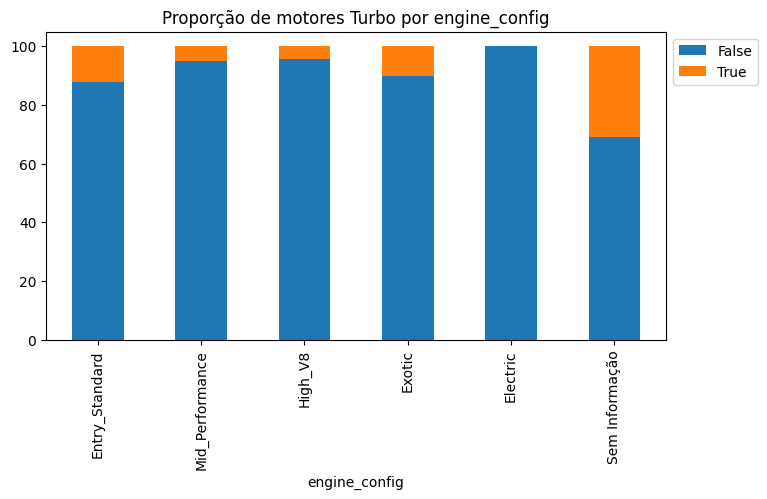

In [514]:
# Plotando gráfico de barras que compara proporção de motores turbo em cada engine_config

# Define ordem das categorias de engine_config para gráfico
ordem = ['Entry_Standard', 'Mid_Performance', 'High_V8', 'Exotic', 'Electric', 'Sem Informação']

# Cria tabela normalizada com proporção de motores turbo
tab = pd.crosstab(df_cars['engine_config'], df_cars['is_turbo'], normalize='index') * 100

# Plota gráfico com tabela ordenada
tab.reindex(ordem).plot(kind='bar', stacked=True, figsize=(8,4))

# Coloca título e formata legenda
plt.title('Proporção de motores Turbo por engine_config')
plt.legend(bbox_to_anchor=(1,1)) # Posiciona legenda fora do gráfico

# Exibe gráfico
plt.show()

A extração da presença de Turbo/Supercharger por categoria de motor validou a consistência dos dados para o modelo de precificação:

* A categoria **Electric** apresenta 100% de registros como False, confirmando a ausência de indução forçada em motores elétricos.

* No grupo **Entry_Standard**, a incidência de 12% reflete a tendência de downsizing, onde motores de baixa litragem utilizam turbocompressores para ganho de eficiência e performance.

* Nas categorias **High_V8** e **Exotic**, a predominância de motores aspirados (acima de 89%) é coerente com modelos esportivos de alta cilindrada.

* O grupo Sem Informação apresenta a maior taxa de identificação positiva (30,8%). Isso demonstra que a variável booleana irá permitir que o modelo diferencie a performance de veículos cujos detalhes de cilindros não foram explicitamente declarados.

## Transmissão (*transmission*)

In [515]:
# Distribuição de frequencia da variável transmission

analisar_distribuicao(df_cars, 'transmission')

--- Análise da Variável: transmission ---
Total de classes únicas (incluindo NaN): 62

                                                                  Frequência Absoluta  Frequência Relativa (%)
transmission                                                                                                  
A/T                                                                              1037                    25.87
8-Speed A/T                                                                       406                    10.13
Transmission w/Dual Shift Mode                                                    398                     9.93
6-Speed A/T                                                                       362                     9.03
6-Speed M/T                                                                       248                     6.19
Automatic                                                                         237                     5.91
7-Speed A/T              

O código a seguir realiza a redução de granularidade da variável *transmission*, consolidando diversas nomenclaturas técnicas em categorias funcionais para o modelo de regressão.

A função utiliza mapeamento de padrões de texto para agrupar variações como A/T, CVT, DCT, PDK e Variable sob o rótulo **Automatic**, enquanto siglas como M/T são classificadas como **Manual**.

O uso da categoria **Other** serve como um filtro de auditoria para identificar inconsistências de preenchimento ou transmissões exóticas, garantindo que o modelo não seja treinado com ruído.

In [516]:
# Definindo novas classes de transmissão, baseadas nas caracteristicas manual x automática

def transmission_cleanup(transmission_string):
    clean_text = str(transmission_string).upper().strip()

    # Identifica tecnologias de câmbio manual
    if any(x in clean_text for x in ['MANUAL', 'M/T', 'MT']):
        return 'Manual'

    # Identifica tecnologias de câmbio automático
    auto_patterns = ['A/T', 'AT', 'AUTOMATIC', 'AUTO', 'CVT', 'DCT', 'VARIABLE','DSG', 'PDK',
        'SHIFT', 'SINGLE', 'FIXED', '1-SPEED', 'OVERDRIVE']
    if any(pattern in clean_text for pattern in auto_patterns):
        return 'Automatic'

    # Fallback
    return 'Other'

# Aplica transformação ao dataset original
df_cars['transmission_grouped'] = df_cars['transmission'].apply(transmission_cleanup)

# Verifica estatísticas dos novos grupos criados
comparativo = df_cars.groupby('transmission_grouped')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo.to_string())

                               mean   median  count            std      min        max
transmission_grouped                                                                  
Automatic              44478.282242  32000.0   3621   75329.425141   2000.0  2954083.0
Manual                 41447.513298  24000.0    376   96132.022944   2300.0  1599000.0
Other                 164467.916667  54498.0     12  242624.888366  14798.0   749950.0


In [517]:
# Analisando os registros que caíram no grupo 'Other'

df_cars[df_cars['transmission_grouped'] == 'Other']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_tier,fuel_group,engine_std,engine_config,engine_hp,engine_displacement,is_turbo,transmission_grouped
5,Acura,ILX 2.4L,2016,136397.0,Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,No,14798.0,Premium,Gasoline,2.4 liter,Sem Informação,NaN,2.4,False,Other
269,Acura,TLX w/A-Spec Package,2022,14896.0,Gasoline,2.0 Liter DOHC Turbo,2,Lunar Silver Metallic,Ebony,None reported,No,39998.0,Premium,Gasoline,2.0 liter dohc turbo,Sem Informação,NaN,2.0,True,Other
476,Acura,MDX w/Technology Package,2023,3415.0,Gasoline,3.5 Liter SOHC,F,White,Parchment.,None reported,No,54998.0,Premium,Gasoline,3.5 liter sohc,Sem Informação,NaN,3.5,False,Other
516,Acura,MDX w/Technology Package,2022,30177.0,Gasoline,3.5L 24V SOHC I-VTEC V6,2,Majestic Black Pearl,Espresso,None reported,No,46598.0,Premium,Gasoline,3.5l 24v sohc i-vtec v6,Mid_Performance,NaN,3.5,False,Other
536,Porsche,911 Carrera S,2017,16701.0,Gasoline,3.0 Liter,–,Red,–,None reported,No,107998.0,Luxury_Exotic,Gasoline,3.0 liter,Sem Informação,NaN,3.0,False,Other
855,Ford,Bronco,1974,6217.0,Gasoline,–,–,Dark Gray Metallic,–,None reported,Yes,115000.0,Mainstream,Gasoline,–,Sem Informação,NaN,NaN,False,Other
916,Porsche,911 Carrera 4S,2018,31678.0,Gasoline,3.0 Liter,–,Silver,–,None reported,No,106798.0,Luxury_Exotic,Gasoline,3.0 liter,Sem Informação,NaN,3.0,False,Other
1236,Toyota,Tacoma TRD Pro,2019,40698.0,Gasoline,3.5L V6 24V PDI DOHC,6-Speed,Super White,Black,None reported,No,42886.0,Mainstream,Gasoline,3.5l v6 24v pdi dohc,Mid_Performance,NaN,3.5,False,Other
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,Gasoline,6.5L V12 48V MPFI DOHC,7-Speed,–,Nero Ade,None reported,Yes,749950.0,Luxury_Exotic,Gasoline,6.5l v12 48v mpfi dohc,Exotic,NaN,6.5,False,Other
1615,Rolls-Royce,Phantom,2023,1560.0,Gasoline,–,–,Tempest,Cobalt Blue,None reported,Yes,599995.0,Luxury_Exotic,Gasoline,–,Sem Informação,NaN,NaN,False,Other


Após uma **análise qualitativa** dos 12 registros residuais, identificamos que a categoria **Other** era composta majoritariamente por inconsistências de preenchimento em modelos convencionais (ex: Acura) e veículos de altíssimo luxo (Lamborghini, Rolls-Royce) com nomenclaturas proprietárias.
Optaremos pela consolidação desses casos na classe **Automatic**, uma vez que todos operam mecanicamente sem pedal de embreagem. Esta decisão elimina o viés de uma categoria pouco representativa.

In [518]:
# Incluindo a classe Other dentro de Automatic

df_cars['transmission_grouped'] = df_cars['transmission_grouped'].replace('Other', 'Automatic')

In [519]:
# Distribuição de frequencia da variável transmission_grouped

analisar_distribuicao(df_cars, 'transmission_grouped')

--- Análise da Variável: transmission_grouped ---
Total de classes únicas (incluindo NaN): 2

                      Frequência Absoluta  Frequência Relativa (%)
transmission_grouped                                              
Automatic                            3633                    90.62
Manual                                376                     9.38


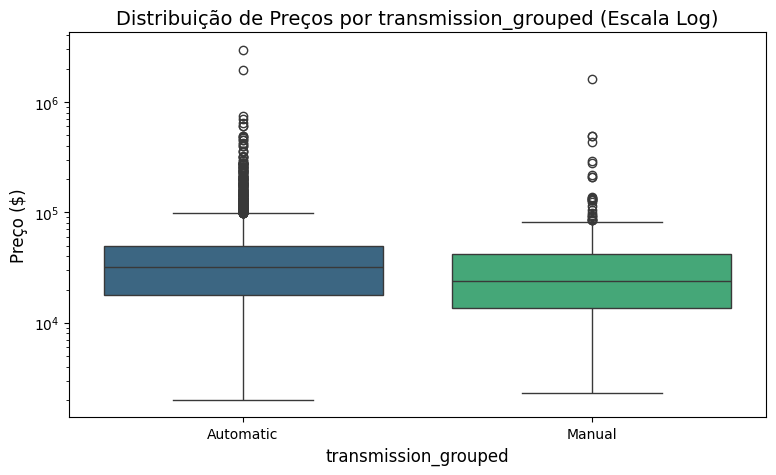

In [520]:
# Criando boxplot dos preços de veículos, nas classes da variável transmission_grouped

boxplot_price(df_cars, 'transmission_grouped')

O boxplot ratifica a segmentação de mercado: a categoria **Manual** apresenta a menor mediana de preços, refletindo a desvalorização dessa tecnologia em veículos convencionais no mercado americano, onde o câmbio automático se tornou o padrão de consumo.

## Cor externa (*ext_col*)

In [521]:
# Distribuição de frequencia da variável ext_col

analisar_distribuicao(df_cars, 'ext_col')

--- Análise da Variável: ext_col ---
Total de classes únicas (incluindo NaN): 319

                                    Frequência Absoluta  Frequência Relativa (%)
ext_col                                                                         
Black                                               905                    22.57
White                                               816                    20.35
Gray                                                496                    12.37
Silver                                              374                     9.33
Blue                                                349                     8.71
Red                                                 261                     6.51
Green                                                74                     1.85
Brown                                                43                     1.07
Gold                                                 42                     1.05
Beige                     

Para a variável de cor externa (*ext_col*), identificou-se inicialmente uma alta cardinalidade, com centenas de variações nominais. O primeiro passo para o tratamento desses dados consiste em uma limpeza para a extração da nomenclatura genérica das cores, reduzindo a complexidade da coluna e padronizando as categorias para a análise.



In [522]:
# Define função que agrupa nomenclaturas diferentes para a mesma cor e joga ocorrências menos comuns em Other

def simplify_color(color):
    c = str(color).lower()

    # Dicionário de mapeamento de cores
    mapping = {
        'White': ['white', 'blanc', 'bianco', 'pearl'],
        'Black': ['black', 'jet', 'ebony', 'obsidian', 'nero', 'onyx'],
        'Gray': ['gray', 'grey', 'granite', 'charcoal', 'slate', 'ash'],
        'Silver': ['silver', 'billet', 'iconic'],
        'Blue': ['blue', 'navy', 'blu', 'indigo', 'azure'],
        'Red': ['red', 'rosso', 'crimson', 'scarlet', 'pimento'],
        'Beige': ['beige', 'tan', 'sand', 'parchment', 'almond', 'ivory'],
        'Brown': ['brown', 'mocha', 'saddle', 'espresso', 'cocoa', 'bronze'],
        'Green': ['green', 'verde', 'emerald', 'olive'],
        'Gold': ['gold'],
        'Orange': ['orange', 'arancio', 'mango'],
        'Yellow': ['yellow', 'giallo']
    }

    # Verifica se alguma palavra-chave está presente na string
    for target_color, keywords in mapping.items():
        if any(word in c for word in keywords):
            return target_color

    return 'Other'

In [523]:
# Simplificando a coluna ext_col

df_cars['ext_col_simple'] = df_cars['ext_col'].apply(simplify_color)

print(df_cars['ext_col_simple'].value_counts(normalize=True)*100)

ext_col_simple
Black     25.342978
White     24.045897
Gray      13.744076
Silver    10.526316
Blue       9.802943
Red        7.657770
Green      2.020454
Other      1.845847
Brown      1.147418
Beige      1.097531
Gold       1.047643
Orange     0.972811
Yellow     0.748316
Name: proportion, dtype: float64


 O segundo passo será consolidar essas 13 cores em 5 categorias principais, baseadas em critérios de liquidez:

 * **Neutral_Dark**: composto por Black e Gray, cores de alta demanda e perfil corporativo.
 * **Neutral_Light**: reúne White e Silver, o padrão de mercado de fácil revenda.
 * **Chroma_Standard**: inclui Blue e Red, cores vibrantes de massa, comuns em modelos de entrada.
 * **Earth_Tones**: agrupa Brown, Beige e Gold, tons sóbrios associados a veículos de luxo.
 * **Vibrant_Rare**: engloba Green, Orange, Yellow e a categoria Other, que são cores de nicho com baixa representatividade individual.

Esta simplificação reduz a dimensionalidade do dataset (após encoding), o que resulta em um modelo de execução mais rápida e com melhor capacidade de generalização para novos dados.

In [524]:
# Define função que agrupa cores em grupos de ext_col
def group_ext(color):

    # Mapeamento cor -> grupo
    mapping = {
        'Black': 'Neutral_Dark', 'Gray': 'Neutral_Dark',
        'White': 'Neutral_Light', 'Silver': 'Neutral_Light',
        'Blue': 'Chroma_Standard', 'Red': 'Chroma_Standard',
        'Brown': 'Earth_Tones', 'Beige': 'Earth_Tones', 'Gold': 'Earth_Tones'
    }

    # Retorna o grupo ou 'Vibrant_Rare' caso a cor não esteja no mapa
    return mapping.get(color, 'Vibrant_Rare')

# Aplica a função aos valores de ext_col
df_cars['ext_col_group'] = df_cars['ext_col_simple'].apply(group_ext)

# Imprime classes de ext_col e sua frequência
print(df_cars['ext_col_group'].value_counts(normalize=True)*100)

ext_col_group
Neutral_Dark       39.087054
Neutral_Light      34.572213
Chroma_Standard    17.460713
Vibrant_Rare        5.587428
Earth_Tones         3.292592
Name: proportion, dtype: float64


In [525]:
# Calculando estatísticas de preço nos grupos de cores

comparativo_precos = df_cars.groupby('ext_col_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos.to_string())

                         mean   median  count            std     min        max
ext_col_group                                                                  
Chroma_Standard  46418.025714  30000.0    700  122038.684007  2300.0  2954083.0
Earth_Tones      28277.727273  17250.0    132   34316.881282  3200.0   217000.0
Neutral_Dark     44130.518188  33000.0   1567   58374.420312  2000.0  1599000.0
Neutral_Light    41657.803752  29970.0   1386   69247.527183  2500.0  1950995.0
Vibrant_Rare     69188.500000  41999.5    224   97118.795276  2300.0   749950.0


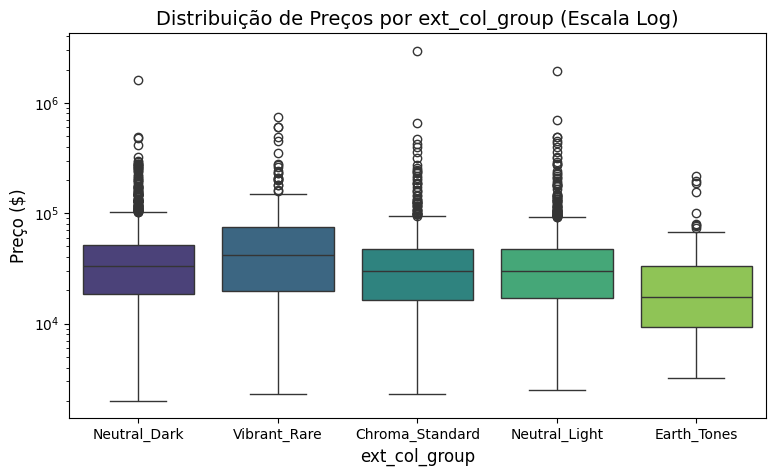

In [526]:
# Criando boxplot dos preços de veículos, nas classes da variável ext_col_group

boxplot_price(df_cars, 'ext_col_group')

A análise dos grupos de cores externas revela padrões distintos de valorização e a presença marcante de valores atípicos (outliers):

* A categoria **Vibrant_Rare** apresenta a maior mediana (41.999 USD), indicando que cores exóticas estão frequentemente associadas a veículos de nicho ou de maior valor agregado nesta base.

* Observa-se uma forte assimetria em todas as categorias, com médias sistematicamente superiores às medianas, sugerindo que modelos de luxo estão distorcendo a média para cima.

* A categoria **Earth_Tones** apresenta o menor ticket médio e mediana, concentrando-se em uma faixa de preço mais acessível e com menor dispersão de valores extremos em comparação aos demais grupos.

Em suma, os gráficos boxplot indicam que a cor não será o fator determinante para a diferenciação de preço no modelo, visto que as medianas das categorias são próximas e a volatilidade interna de cada grupo é bastante alta.

## Cor interna (*int_col)*

In [527]:
# Distribuição de frequencia da variável int_col

analisar_distribuicao(df_cars, 'int_col')

--- Análise da Variável: int_col ---
Total de classes únicas (incluindo NaN): 156

                       Frequência Absoluta  Frequência Relativa (%)
int_col                                                            
Black                                 2025                    50.51
Beige                                  538                    13.42
Gray                                   472                    11.77
Brown                                  157                     3.92
–                                      133                     3.32
White                                  127                     3.17
Red                                    126                     3.14
Jet Black                               59                     1.47
Ebony                                   44                     1.10
Blue                                    29                     0.72
Orange                                  20                     0.50
Silver                           

Similarmente ao que foi feito para as cores externas, o primeiro passo para o tratamento da coluna *int_col* consiste na extração da nomenclatura genérica das cores, reduzindo a complexidade e padronizando as categorias para a análise.

In [528]:
# Simplificando a coluna int_col

df_cars['int_col_simple'] = df_cars['int_col'].apply(simplify_color)

print(df_cars['int_col_simple'].value_counts(normalize=True)*100)

int_col_simple
Black     55.400349
Beige     14.093290
Gray      12.596658
Other      4.764280
Brown      4.165627
White      3.342479
Red        3.317536
Blue       0.848092
Orange     0.573709
Silver     0.399102
Gold       0.249439
Green      0.199551
Yellow     0.049888
Name: proportion, dtype: float64


Para a variável de cor interna, a limpeza revelou que a cor Black domina mais de 55% da base. Aplicaremos também uma simplificação de 5 categorias para refletir o padrão de acabamento e a percepção de valor dos veículos.

* **Standard_Dark**: é composto apenas por Black, representando a maior fatia do mercado.
* **Standard_Light**: reúne Beige e Gray, cores tradicionais que somam mais de 26% dos dados e oferecem sensação de amplitude.
* **Premium_Earth**: consolida Brown e White, tons que frequentemente sinalizam sofisticação e acabamentos diferenciados.
* **Chroma_Sport**: inclui Red e Blue, cores geralmente associadas a pacotes de design esportivo.
* **Exotic_Rare**: engloba Orange, Silver, Gold, Green, Yellow e a categoria Other, unindo opções de nicho com baixa frequência.

Este tratamento garante que o modelo não sofra com a dispersão dos dados e consiga capturar o impacto real do acabamento interno no preço final.

In [529]:
# Define função que agrupa cores em grupos de int_col
def group_int(color):

    # Mapeamento cor -> grupo
    mapping = {
        'Black': 'Standard_Dark',
        'Beige': 'Standard_Light',
        'Gray': 'Standard_Light',
        'Brown': 'Premium_Earth',
        'White': 'Premium_Earth',
        'Red': 'Chroma_Sport',
        'Blue': 'Chroma_Sport'
    }

    # Busca a cor no mapa, se não existir, classifica como 'Exotic_Rare'
    return mapping.get(color, 'Exotic_Rare')

# Aplica a função aos valores de int_col
df_cars['int_col_group'] = df_cars['int_col_simple'].apply(group_int)

# Imprime classes de int_col e sua frequência
print(df_cars['int_col_group'].value_counts(normalize=True)*100)

int_col_group
Standard_Dark     55.400349
Standard_Light    26.689948
Premium_Earth      7.508107
Exotic_Rare        6.235969
Chroma_Sport       4.165627
Name: proportion, dtype: float64


In [530]:
# Calculando estatísticas de preço nos grupos de cores

comparativo_precos = df_cars.groupby('int_col_group')['price'].agg(['mean', 'median', 'count','std','min','max'])
print(comparativo_precos)

                        mean   median  count            std     min        max
int_col_group                                                                 
Chroma_Sport    63260.107784  42000.0    167   81128.766893  4900.0   695000.0
Exotic_Rare     61731.792000  38798.0    250   81468.822597  2500.0   599000.0
Premium_Earth   57790.099668  39998.0    301  119512.832230  4500.0  1950995.0
Standard_Dark   45866.369653  34000.0   2221   59478.450975  2500.0  1599000.0
Standard_Light  31170.399065  20000.0   1070   94600.192805  2000.0  2954083.0


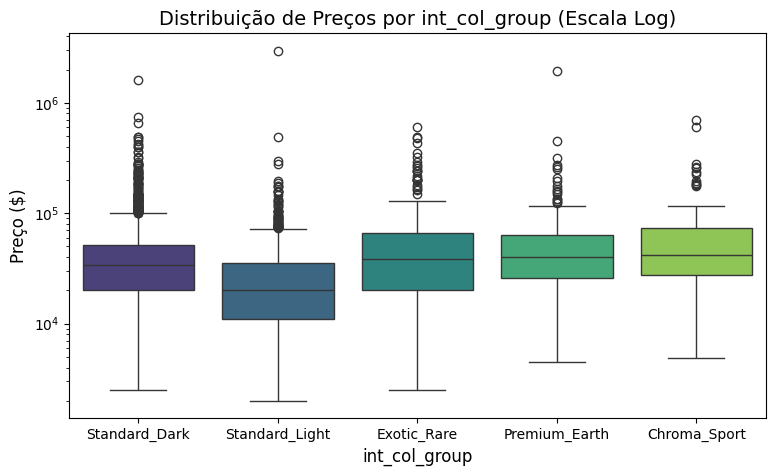

In [531]:
# Criando boxplot dos preços de veículos, nas classes da variável int_col_group

boxplot_price(df_cars, 'int_col_group')

A partir do boxplot acima podemos observar:

* As categorias **Chroma_Sport, Exotic_Rare e Premium_Earth** apresentam as maiores medianas (entre 38k USD e 42k USD), sugerindo que interiores coloridos, exóticos ou em tons de luxo (como marrom e branco) estão frequentemente atrelados a veículos de maior valor agregado.

* Observa-se uma forte assimetria em todas as classes, com médias sistematicamente superiores às medianas, indicando que modelos de luxo estão puxando as médias para cima.

* A categoria **Standard_Dark** confirma sua posição como o padrão de volume do mercado, tendo um desvio padrão inferior aos demais grupos de nicho.

Em suma, o boxplot demonstra que a cor interna não será o fator determinante para a diferenciação de preço no modelo, visto que as medianas das categorias são próximas e a volatilidade interna de cada grupo é extremamente alta, indicando que o acabamento pode ser um preditor complementar.

## Ano do modelo (*model_year*)

In [532]:
# Distribuição de frequencia da variável model_year

analisar_distribuicao(df_cars, 'model_year')

--- Análise da Variável: model_year ---
Total de classes únicas (incluindo NaN): 34

            Frequência Absoluta  Frequência Relativa (%)
model_year                                              
2022                        354                     8.83
2021                        350                     8.73
2020                        322                     8.03
2018                        315                     7.86
2019                        297                     7.41
2016                        268                     6.68
2017                        259                     6.46
2015                        228                     5.69
2023                        226                     5.64
2014                        181                     4.51
2013                        158                     3.94
2012                        141                     3.52
2011                        124                     3.09
2008                        113                     2.82
201

A transformação da variável *model_year* em *vehicle_age* (idade do veículo) foi escolhida pelos seguintes motivos:

* A idade reduz a escala numérica. Números menores e começando em zero são matematicamente mais eficientes para a convergência de algoritmos e tornam a análise mais intuitiva.
* Se o modelo for usado no futuro terá dificuldade de extrapolar o ano. Já o conceito de idade, permanece válido independentemente do ano civil.
* A desvalorização automotiva é uma função do tempo de uso e não do rótulo do calendário. A idade correlaciona-se diretamente com o desgaste físico e a obsolescência tecnológica.

Regra Aplicada: *vehicle_age* = 2024 - *model_year* (2024 é o ano máximo da base de dados).

In [533]:
# Criando uma nova coluna de idade, usando 2024 como referência

df_cars['vehicle_age'] = 2024 - df_cars['model_year']

In [534]:
df_cars['vehicle_age'].describe()


,vehicle_age
count,4009.000000
mean,8.484410
std,6.104816
min,0.000000
25%,4.000000
50%,7.000000
75%,12.000000
max,50.000000


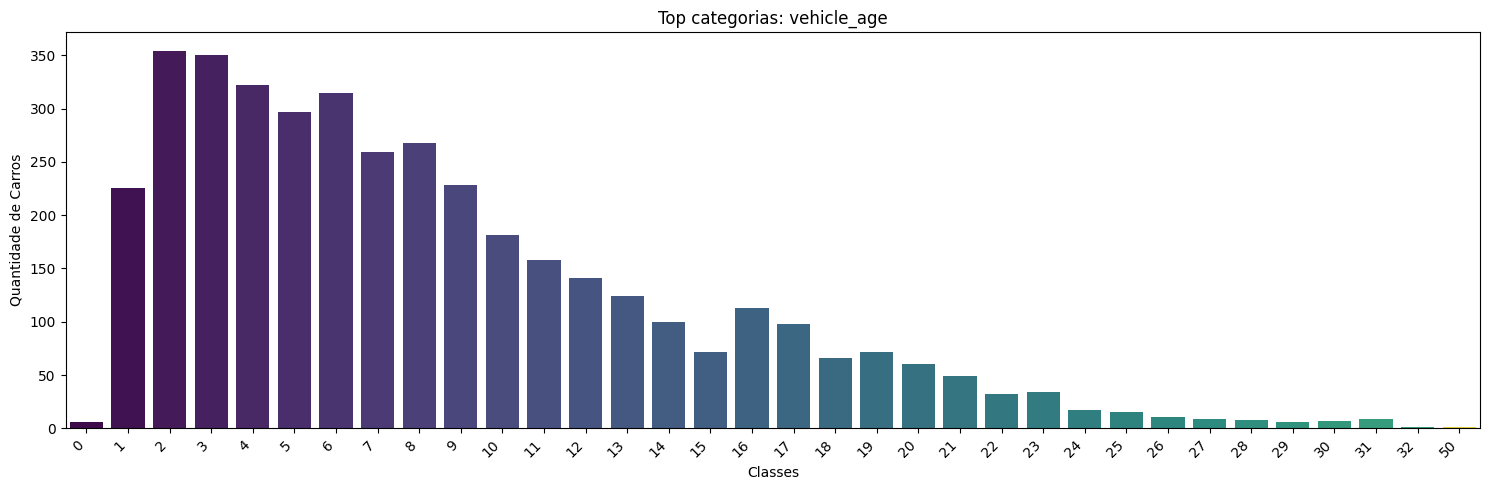

In [535]:
# Gráfico de barras das categorias da variável vehicle_age

grafico_distribuicao(df_cars, 'vehicle_age')

A transformação da variável *model_year* em *vehicle_age* (idade do veículo) preservou a estrutura da distribuição, mas inverteu sua polaridade: a moda agora se concentra em 2 anos.
A assimetria, que anteriormente era negativa (concentrada em anos recentes), tornou-se positiva, apresentando uma cauda longa a direita que representa os veículos de idade avançada.

## Seleção das variáveis para divisão entre treino e teste

In [536]:
# Selecionando no dataset trabalhado apenas as colunas de interesse para análise

# Define lista de colunas de interesse para análises finais (note que neste momento abandonamos também a coluna clean_title)
cols_analise = [
    'brand_tier', 'model', 'vehicle_age',
    'milage', 'fuel_group', 'engine_config', 'engine_hp',
    'engine_displacement', 'is_turbo', 'transmission_grouped',
    'ext_col_group', 'int_col_group', 'accident', 'price'
]

# Copia para o novo dataframe apenas as colunas de interesse
df_modelagem = df_cars[cols_analise].copy()

# Exibe primeiras linhas de novo dataframe limpo e selecionado
df_modelagem.head()

,brand_tier,model,vehicle_age,milage,fuel_group,engine_config,engine_hp,engine_displacement,is_turbo,transmission_grouped,ext_col_group,int_col_group,accident,price
0,Mainstream,Utility Police Interceptor Base,11,51000.0,Other Combustion,Mid_Performance,300.0,3.7,False,Automatic,Neutral_Dark,Standard_Dark,At least 1 accident or damage reported,10300.0
1,Mainstream,Palisade SEL,3,34742.0,Gasoline,Mid_Performance,NaN,3.8,False,Automatic,Vibrant_Rare,Standard_Light,At least 1 accident or damage reported,38005.0
2,Premium,RX 350 RX 350,2,22372.0,Gasoline,Sem Informação,NaN,3.5,False,Automatic,Chroma_Standard,Standard_Dark,None reported,54598.0
3,Premium,Q50 Hybrid Sport,9,88900.0,Green Energy,Mid_Performance,354.0,3.5,False,Automatic,Neutral_Dark,Standard_Dark,None reported,15500.0
4,Premium,Q3 45 S line Premium Plus,3,9835.0,Gasoline,Entry_Standard,NaN,2.0,True,Automatic,Neutral_Light,Standard_Dark,None reported,34999.0


# 6. Divisão em bases de treino e de teste

In [537]:
# Divisão entre variáveis preditoras e alvo

X = df_modelagem.drop(columns=['price'])
y = df_modelagem['price']

In [538]:
# Definindo o problema

print("Tipo de problema: regressao")
print("Target: price")
print("Número de features:", len(X.columns))
print("Features:", X.columns.tolist())


Tipo de problema: regressao
Target: price
Número de features: 13
Features: ['brand_tier', 'model', 'vehicle_age', 'milage', 'fuel_group', 'engine_config', 'engine_hp', 'engine_displacement', 'is_turbo', 'transmission_grouped', 'ext_col_group', 'int_col_group', 'accident']


In [539]:
# Divisão em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (3207, 13) | Teste: (802, 13)


In [540]:
# Criando os folds

num_particoes = 10
kfold = KFold(n_splits = num_particoes, shuffle=True, random_state=SEED)

A separação dos dados foi estruturada em duas etapas para garantir a idoneidade do modelo:

* Divisão Treino/Teste (Holdout 80/20): Isolamos 20% dos dados para teste e destinamos 80% para o treinamento. Essa proporção é ideal para o volume do dataset, pois garante dados suficientes para o aprendizado do algoritmo e resguarda uma amostra representativa para a avaliação final.

* Validação Cruzada: Aplicada sobre a base de treino, configuramos o K-Fold com 10 partições. Essa abordagem é indispensável porque treina e valida o modelo 10 vezes em subconjuntos rotativos diferentes, mitigando o risco de encontrarmos uma métrica de performance muito dependente do acaso em uma divisão única. Como o objetivo é prever uma variável contínua, a estratificação de classes não se aplica. Para assegurar a homogeneidade dos blocos, ativamos o parâmetro shuffle=True, que embaralha as linhas e neutraliza biases de ordenação.

* Prevenção de Vazamento de Dados (Data Leakage): Ao separar o conjunto de teste logo no início e aplicar a validação cruzada apenas sobre o bloco de treino, garantimos que as próximas etapas de pré-processamento não utilizarão informações do conjunto de teste. O teste permanece inédito, simulando o comportamento do modelo em produção.

# 7. Pré-processamento e pipeline

##7.1 Tratamento de missings

Recapitulando a análise de dados faltantes realizada na seção de Análise Exploratória, o dataset original apresentava registros nulos nas colunas fuel_type, accident e clean_title. Como as estratégias de tratamento adotadas basearam-se em regras de negócio fixas e em distribuições globais, esses preenchimentos puderam ser executados de forma segura antes da divisão entre os conjuntos de treino e teste, sem risco de vazamento de dados (data leakage):

* ***fuel_type***: Identificamos que a totalidade das instâncias nulas correspondia a modelos de veículos puramente elétricos. Dessa forma, substituímos os valores faltantes pela categoria 'Electric'.

* ***accident***: Aproximadamente 73% dos registros continham o valor 'None reported'. Adicionalmente, a análise exploratória revelou que as métricas de centralidade (média e mediana) de preço das instâncias nulas eram similares às da classe majoritária. Diante disso, os missings foram preenchidos com a classe mais frequente.

* ***clean_title***: Optou-se pela exclusão integral desta variável do escopo de modelagem. A ausência de uma interpretação semântica confiável para os 15% de dados faltantes justificou o descarte da coluna.

Conforme determinado na análise exploratória, as variáveis ***engine_hp*** (potência) e ***engine_displacement*** (cilindrada) receberão uma estratégia de imputação por mediana agrupada.

O preenchimento dos valores faltantes será realizado com base na mediana observada em cada categoria da variável condicional *engine_config*. A opção pela mediana, em detrimento da média, justifica-se por sua robustez a distorções por outliers. Para os registros em que a configuração do motor for desconhecida, adotaremos a mediana global do dataset como métrica de contingência.

Tratamento de Exceção para **Veículos Elétricos**: Na categoria 'Electric', a especificação de litragem não se aplica ao motor elétrico por restrições físicas, ocorrendo apenas em casos particulares de híbridos ou extensores de autonomia. Por questões de consistência técnica e alinhamento ao conhecimento de domínio, adotou-se uma regra de imputação determinística, fixando o preenchimento de engine_displacement em 0.0 para todos esses veículos.

In [541]:
# Transformador customizado para missings (Padrão Scikit-Learn)

class ImputadorCustomizadoAutos(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Aprende as medianas apenas com o fold de treino atual
        X_copy = X.copy()
        X_copy.loc[X_copy['engine_config'] == 'Electric', 'engine_displacement'] = 0.0

        self.med_disp_grupos_ = X_copy.groupby('engine_config')['engine_displacement'].median()
        self.med_hp_grupos_ = X_copy.groupby('engine_config')['engine_hp'].median()
        self.med_disp_global_ = X_copy['engine_displacement'].median()
        self.med_hp_global_ = X_copy['engine_hp'].median()
        return self

    def transform(self, X):
        X_out = X.copy()

        # Aplica as regras aprendidas no fit
        X_out.loc[X_out['engine_config'] == 'Electric', 'engine_displacement'] = 0.0
        X_out['engine_displacement'] = X_out['engine_displacement'].fillna(X_out['engine_config'].map(self.med_disp_grupos_)).fillna(self.med_disp_global_)
        X_out['engine_hp'] = X_out['engine_hp'].fillna(X_out['engine_config'].map(self.med_hp_grupos_)).fillna(self.med_hp_global_)
        return X_out

##7.2 Tratamento de outliers

### Quilometragem (*milage*) e Idade do veículo (*vehicle_age*):

O tratamento de valores extremos nas variáveis de ***milage*** e ***vehicle_age*** é uma etapa fundamental para garantir a assertividade das predições. As principais razões são:

1. Veículos com idade ou rodagem excessivas apresentam pouca amostra no dataset, o que impede o modelo de aprender padrões consistentes.
2. Nas faixas extremas de idade e quilometragem, o preço passa a ser influenciado por fatores subjetivos que a base de dados não captura, como o estado de conservação.

Optamos pela Exclusão Baseada no Método IQR, definindo o corte no limite superior do Boxplot (Q3 + 1,5 x IQR) e no limite inferior (Q1 - 1,5 x IQR).

Remover os registros atípicos significa mitigar ruídos que prejudicam a performance do modelo.

In [542]:
# Remove outliers das colunas milage e vehicle_age (compatível com Pipeline do imblearn)

class RemovedorOutliersIQR:

    def __init__(self):
        # Obrigatório para o imblearn identificar que o passo altera X e y simultaneamente
        self._sampling_type = "X_y"

    def fit(self, X, y=None):
        return self

    def fit_resample(self, X, y):
        X_out = X.copy()
        y_out = y.copy()

        # Calcula o IQR das colunas de interesse
        for col in ['milage', 'vehicle_age']:
            Q1 = X_out[col].quantile(0.25)
            Q3 = X_out[col].quantile(0.75)
            IQR = Q3 - Q1

            # Cria a máscara dos dados que estão dentro do limite aceitável
            mascara = (X_out[col] >= Q1 - 1.5 * IQR) & (X_out[col] <= Q3 + 1.5 * IQR)

            # Filtra simultaneamente os recursos (X) e o alvo (y) mantendo o alinhamento dos índices
            X_out = X_out[mascara]
            y_out = y_out[mascara]

        return X_out, y_out

### Potência (*engine_hp*) e Cilindradas (*engine_displacement*):

Como comentado anteriormente na etapa de Feature Engineering, não realizaremos o tratamento de outliers em Potência (***engine_hp***) e Cilindradas (***engine_displacement***) porque os valores extremos são tecnicamente consistentes com suas categorias de motor, representando variações reais de engenharia e não erros de dados.

Manter esses extremos é fundamental para que o modelo consiga diferenciar o valor de mercado de um carro popular de um veículo de alta performance.

### Preço (*price*):

Para a variável alvo ***price***, a mitigação dos efeitos dos valores extremos não será realizada por meio de exclusão de registros, mas sim pela aplicação da escala logarítmica via TransformedTargetRegressor. Esta transformação matemática atua diretamente na compressão da cauda longa de veículos de superluxo, estabilizando a variância e aproximando a distribuição de uma curva normal. Dessa forma, preservamos os supercarros no dataset, cruciais para o aprendizado do modelo, enquanto neutralizamos o viés que seus valores absolutos causariam nos algoritmos de regressão.
Essa transformação será aplicada no treinamento do modelo de regressão.

**Nota:** Na primeira versão do pipeline de pré-processamento, a variável alvo *price* foi tratada para outliers adotando uma estratégia de IQR segmentado por *brand_tier*. Diferente de um corte global, que excluiria arbitrariamente os veículos de luxo, essa abordagem calculava os limites de detecção dentro de cada nicho de mercado.

No entanto, a estratégia de utilizar a transformação logarítmica (mantida nesta versão final) gerou melhores resultados para os modelos e eliminou a necessidade de exclusão de registros.

##7.3 Transformação de colunas

###Target Encoding:

Aplicamos a técnica de Target Encoding para o tratamento da **variável model**, caracterizada por sua alta cardinalidade original (1.898 classes). Esta abordagem substitui cada categoria textual pelo valor médio da variável alvo (price) associado a ela na base de treino, compactando centenas de modelos de veículos em uma única coluna numérica.

Para mitigar o risco de overfitting em modelos raros ou sub-representados no dataset, a transformação utiliza uma suavização automática (smooth="auto"), que pondera a média local com a média global do dataset. Essa estratégia preserva o poder preditivo do modelo do carro sem inflar desnecessariamente a dimensionalidade da matriz, otimizando o custo computacional e o tempo de treinamento dos algoritmos de regressão.

###Dummy Encoding:

Realizaremos a conversão das **variáveis categóricas** em um formato numérico processável, através da técnica de Dummy Encoding. Este passo é crucial, pois algoritmos de regressão operam sobre matrizes matemáticas e não conseguem interpretar dados textuais diretamente.

A escolha do Dummy encoding (uma variante do One-Hot Encoding), busca evitar problemas de multicolinearidade, ao omitir uma variável de referência para cada grupo.

Optou-se ainda pelo Dummy Encoding em vez do Ordinal Encoding para evitar hierarquias artificiais, visto que as distribuições de preço revelaram saltos desproporcionais, mesmo para as variáveis com hierarquia aparente (como *brand_tier*, por exemplo). Essa abordagem permite que o modelo capture variações não lineares e especificidades de cada nicho.

Dado que a alta cardinalidade original foi previamente mitigada pela criação de agrupamentos semânticos, o impacto na dimensionalidade do dataset permanece controlado, resultando em um conjunto de colunas binárias eficientes para o treinamento do modelo.

###Normalização:

Aplicamos a Normalização às **variáveis numéricas** preditoras: *vehicle_age*, *milage*, *engine_hp*, *engine_displacement* e *model* (após tratamento de target encoding). Esta transformação é fundamental para garantir que todas as variáveis numéricas estejam contidas no mesmo intervalo [0, 1], evitando que modelos de regressão baseados em distância ou com penalização de coeficientes atribuam importância desproporcional a atributos com maiores ordens de grandeza.

A escolha pela Normalização em detrimento da Padronização justifica-se pelo fato de as variáveis do projeto não seguirem necessariamente uma distribuição normal. A Normalização preserva a estrutura original das distâncias entre os dados, apenas comprimindo-os em uma escala comum, o que facilita a convergência de algoritmos de aprendizado de máquina sem distorcer a relação entre os atributos.

Mantivemos a variável price em sua escala original de saída para garantir a interpretabilidade direta dos resultados em moeda, facilitando a análise de negócio. A estabilização da sua distribuição fortemente assimétrica será delegada à transformação logarítmica incorporada diretamente na etapa de modelagem, tornando qualquer normalização ou exclusão rígida de registros no target desnecessária.

In [543]:
# Criação do pipeline de transformação das colunas

cols_target_encoding = ['model']
cols_dummy_encoding = ['brand_tier', 'fuel_group', 'engine_config', 'is_turbo',
    'transmission_grouped', 'ext_col_group', 'int_col_group', 'accident']
cols_normalizacao = ['vehicle_age', 'milage', 'engine_hp', 'engine_displacement']

# Configuração do pipeline para a variável model (TargetEncoding + Normalização)
pipeline_model = Pipeline(steps=[
    ('encoder', TargetEncoder(smooth="auto", target_type="continuous", random_state=SEED)),
    ('normalizador_model', MinMaxScaler())])

# Configuração do processador de colunas
processador_colunas = ColumnTransformer(
    transformers=[
        # Aplicacão do Target Encoding + Normalização
        ('target_enc_com_escala', pipeline_model, cols_target_encoding),

        # Dummy Encoding (drop='first'para evitar problemas de multicolinearidade)
        ('dummy_enc', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'), cols_dummy_encoding),

        # Normalização direta para numéricas contínuas
        ('normalizador', MinMaxScaler(), cols_normalizacao)],

    remainder='passthrough'
)

##7.4 Pipeline de pré-processamento

Para organizar o tratamento dos dados e evitar o risco de vazamento de dados (data leakage), criamos um pipeline que junta todas as etapas em um único fluxo. Esse comando garante que o tratamento de nulos, a remoção de outliers e o enconding das colunas sejam calculados de forma isolada para cada bloco de treino e teste, impedindo que informações de teste contaminem o aprendizado do modelo.

In [544]:
# Configura pipeline de pré-processamento (pós split treino e teste)

pre_processamento = Pipeline(steps=[
    ('missings', ImputadorCustomizadoAutos()),
    ('outliers', RemovedorOutliersIQR()),
    ('enc_scale', processador_colunas)
])

# 8. Baseline e modelos candidatos

Nesta etapa, definimos a estratégia de modelagem para identificar o algoritmo mais capacitado para estimar o preço dos veículos usados. O objetivo deste capítulo é mapear os modelos candidatos e confrontá-los com as restrições e requisitos do nosso dataset, garantindo que as escolhas sejam logicamente sustentadas antes de iniciar a fase de treinamento.

**Coerência do Baseline:** O baseline escolhido é a mediana dos preços do conjunto de treino. Trata-se de uma referência coerente, pois estabelece a performance mínima que qualquer modelo precisaria superar. Se um algoritmo complexo não for capaz de performar melhor do que simplesmente chutar a mediana do mercado para todos os carros, sua complexidade não se justifica. A escolha da mediana apoia-se em critérios estatísticos, dado que ela é a medida de tendência central que minimiza naturalmente o indicador principal de sucesso do projeto, o MAPE.

**Tipo e Tamanho dos Dados:** O dataset possui cerca de 4.000 registros, um volume moderado que se ajusta a modelos clássicos e ensembles de tamanho médio. Algoritmos não-lineares baseados em árvores e em Ensembles são adequados, pois lidam de forma nativa com as interações complexas entre atributos categóricos e numéricos.

**Normalização e Encoding**: Há uma disparidade crítica de grandezas no dataset (quilometragem na casa das centenas de milhares contra anos em unidades). Modelos baseados em distância (KNN) e margens (SVM) exigem obrigatoriamente a normalização prévia dos dados para que variáveis de maior magnitude não governem os cálculos de forma artificial. Além disso, como todos os algoritmos operam sobre matrizes matemáticas, as strings do dataset exigem transformações de encoding: aplicamos o Dummy Encoding para variáveis menores e o Target Encoding para a alta cardinalidade da coluna model.

**Importância do Tratamento de Outliers:** O tratamento de valores extremos em quilometragem e idade é essencial para modelos lineares (LinearRegression, Ridge) e baseados em distância (KNN). Esses algoritmos são muito sensíveis a outliers, pois pontos discrepantes distorcem a inclinação da reta de regressão e deformam o cálculo das distâncias, puxando as previsões para longe da realidade da maioria dos dados. Já os modelos baseados em árvores e ensembles são mais robustos a outliers, uma vez que suas decisões ocorrem por quebras sequenciais.

**Alta Cardinalidade na coluna model**: O dataset possui quase 1.900 modelos de carros para apenas 4.009 registros. Ao aplicar o Target Encoding, essa coluna passa a carregar informação baseada no preço médio em dólares de cada modelo. Para viabilizar esse processo em uma regressão, é indicado configurar o encoder com o parâmetro target_type="continuous", caso contrário, a validação interna poderia colapsar.

**Presença de Variáveis Relacionadas (Multicolinearidade)**: Atributos como Potência (engine_hp) e Cilindrada (engine_displacement), ou Idade (vehicle_age) e Quilometragem (milage), carregam informações correlacionadas. Modelos lineares têm mais dificuldade para aprender o impacto individual de cada uma delas, enquanto os Ensembles de Árvores simplesmente escolhem a melhor variável a cada quebra, sem perda de performance.

**Interpretabilidade, Tempo e Custo Computacional**: O foco do MVP é o equilíbrio entre precisão e viabilidade. Embora modelos lineares ofereçam alta interpretabilidade, eles costumam falhar em capturar nuances não-lineares de depreciação. Por outro lado, arquiteturas de Ensemble (Bagging, Random Forest, Gradient Boosting e XGBoost) abrem mão de parte da interpretabilidade direta em troca de um ganho expressivo de precisão. Dado o tamanho controlado do dataset, o custo computacional e o tempo de processamento desses comitês permanecem viáveis para o ambiente de execução do Google Colab.

In [545]:
# Avaliação do modelo ingênuo (Baseline)

# Configura o pipeline com modelo Dummy, baseado na mediana
dummy_envelopado_com_log = TransformedTargetRegressor(
        regressor=DummyRegressor(strategy='median'),
        func=np.log1p,
        inverse_func=np.expm1
    )

pipeline_dummy = Pipeline(steps=pre_processamento.steps + [('dummy', dummy_envelopado_com_log)])

# Captura o tempo inicial de execução da célula
t0 = time.time()

# Executa a validação cruzada
cv_results_dummy = cross_validate(
    estimator=pipeline_dummy,
    X=X_train,
    y=y_train,
    cv=kfold,
    scoring={'mape': 'neg_mean_absolute_percentage_error',
             'mse': 'neg_mean_squared_error',
             'r2': 'r2'}
)

# Calcula o tempo total real gasto por toda a esteira do pipeline
train_time = time.time() - t0

# Calcula o RMSE individual de cada fold antes de extrair a média
rmse_por_fold = np.sqrt(abs(cv_results_dummy['test_mse']))
rmse_medio = rmse_por_fold.mean()

# Calcula a média dos folds para as demais métricas obtidas
mape_medio = abs(cv_results_dummy['test_mape'].mean()) * 100
r2_medio = cv_results_dummy['test_r2'].mean()

# Monta dataframe para exibição
df_resumo = pd.DataFrame(
    data=[mape_medio, rmse_medio, r2_medio, train_time],
    index=['MAPE (%)', 'RMSE (U$)', 'R²', 'Tempo de Execução Total (s)'],
    columns=['Dummy Regressor (Mediana)']
)

df_resumo.round(3)

,Dummy Regressor (Mediana)
MAPE (%),92.641
RMSE (U$),68080.665
R²,-0.043
Tempo de Execução Total (s),2.053


Para a rodada de experimentos, os seguintes modelos foram integrados ao pipeline:

* Abordagem Linear: Linear Regression, Ridge e Lasso
* Abordagem de Distância e Margem: KNN Regressor e SVM Regressor
* Abordagem de Árvore Única: Decision Tree (CART).
* Abordagem de Ensembles de Árvores: Bagging Regressor, Random Forest, Extra Trees, AdaBoost, Gradient Boosting e Voting Regressor.
* Abordagem de Alta Performance: XGBoost Regressor, incluído como o desafiante devido ao seu forte poder de regularização nativa contra overfitting.

In [546]:
# Definindo os modelos candidatos

models = []

models.append(('LR', LinearRegression()))
models.append(('Ridge', Ridge()))
models.append(('Lasso', Lasso()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor(random_state=SEED)))
models.append(('SVM', SVR()))
models.append(('Bagging', BaggingRegressor(estimator=DecisionTreeRegressor(random_state=SEED), n_estimators=100, random_state=SEED)))
models.append(('RF', RandomForestRegressor(n_estimators=100, max_features=3, random_state=SEED)))
models.append(('ET', ExtraTreesRegressor(n_estimators=100, max_features=3, random_state=SEED)))
models.append(('Ada', AdaBoostRegressor(n_estimators=100, random_state=SEED)))
models.append(('GB', GradientBoostingRegressor(n_estimators=100, random_state=SEED)))
models.append(('XGB', XGBRegressor(n_estimators=100, random_state=SEED)))

estimators = [('Ridge', Ridge()),('CART', DecisionTreeRegressor(random_state=SEED)),('KNN', KNeighborsRegressor())]
models.append(('Voting', VotingRegressor(estimators)))

#9. Treinamento e avaliação inicial

Nesta etapa, realizamos um torneio de algoritmos para avaliar o desempenho de diferentes famílias de modelos preditivos sob as mesmas condições de validação cruzada. O objetivo é testar os modelos com o mesmo pré-processamento, permitindo identificar de forma justa qual estrutura se adapta melhor ao nosso problema antes de avançar para a otimização.

Para a variável alvo (*price*), conforme definido no planejamento, a mitigação dos efeitos dos valores extremos foi feita aplicando a escala logarítmica via TransformedTargetRegressor. Essa transformação matemática comprime a cauda longa dos veículos de superluxo e estabiliza a variância durante o treino, sendo desfeita automaticamente na etapa de predição para que os erros da tabela reflitam a escala real em dólares.

In [547]:
# Torneio de algoritmos com validação cruzada

# Lista para acumular os dicionários de resultados de cada modelo
lista_resultados = []

for name, model in models:

    # Captura o tempo inicial de execução da célula
    t0 = time.time()

    # Envelopa o modelo para aplicar logaritmo no treino e exponencial na previsão
    modelo_envelopado_com_log = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # Define pipeline global que inclui o pré-processamento e o modelo envelopado com escala logarítmica
    pipeline_global = Pipeline(steps=pre_processamento.steps + [('regressor', modelo_envelopado_com_log)])

    # Executa a validação cruzada de cada modelo
    cv_results = cross_validate(
        estimator=pipeline_global,
        X=X_train,
        y=y_train,
        cv=kfold,
        scoring={
            'mse': 'neg_mean_squared_error',
            'mape': 'neg_mean_absolute_percentage_error',
            'r2': 'r2'
        }
    )

    # Calcula o tempo total real gasto por toda a esteira do pipeline
    train_time_total = time.time() - t0

    # Calcula a média dos folds para cada métrica com as devidas correções
    rmse_por_fold = np.sqrt(abs(cv_results['test_mse']))
    rmse_final = rmse_por_fold.mean()
    mape_final = abs(cv_results['test_mape'].mean()) * 100
    r2_final = cv_results['test_r2'].mean()

    # Cria o registro deste modelo específico
    registro_modelo = {
        'Modelo': name,
        'MAPE (%)': mape_final,
        'RMSE (U$)': rmse_final,
        'R²': r2_final,
        'Tempo de Execução (s)': train_time_total
    }

    # Guarda o resultado na lista
    lista_resultados.append(registro_modelo)

# Transforma a lista de resultados em dataframe
df_torneio = pd.DataFrame(lista_resultados)

# Define o nome do modelo como o índice da tabela
df_torneio.set_index('Modelo', inplace=True)

# Exibe a tabela final do torneio, ordenada do menor RMSE para o maior
df_torneio.sort_values(by='MAPE (%)', ascending=True, inplace=True)

# Exibe a tabela formatando os números de ponto flutuante diretamente na visualização
tabela = df_torneio.style.format({
    'MAPE (%)': '{:.2f}%',
    'RMSE (U$)': '{:,.2f}',
    'R²': '{:.4f}',
    'Tempo de Execução (s)': '{:.2f}s'
})

display(tabela)

,MAPE (%),RMSE (U$),R²,Tempo de Execução (s)
Modelo,,,,
GB,22.79%,"40,280.64",0.7100,7.00s
XGB,22.79%,"39,703.08",0.7239,1.95s
Bagging,22.88%,"38,824.13",0.7298,23.99s
RF,23.33%,"44,722.58",0.6447,6.55s
SVM,24.19%,"43,785.38",0.6569,5.14s
ET,25.03%,"44,342.94",0.6517,6.39s
Voting,30.44%,"50,265.67",-0.1703,1.43s
Ada,34.18%,"49,122.24",0.5379,6.05s
KNN,41.12%,"50,662.82",0.4930,2.62s


Com base na tabela consolidada do torneio, extraímos as seguintes conclusões práticas:
* Superação do Baseline: Conforme esperado, os modelos mais robustos superaram o Baseline com folga. O algoritmo XGBoost alcançou o objetivo central de negócio ao entregar o menor MAPE absoluto do torneio (22,79%), empatado com o Gradient Boosting (GB), enquanto o algoritmo Bagging liderou em termos absolutos com o menor RMSE (USD 38.824,13) e o maior $R^2$ (0,7298).
* Suficiência das Métricas: O trio de métricas provou-se complementar e ideal para o problema, com o MAPE atuando com sucesso como nossa métrica principal. Por medir o erro percentual relativo, o MAPE trouxe a interpretabilidade necessária para o negócio e para o usuário final (o vendedor individual), traduzindo o desvio em uma visão realista de margem de mercado (em torno de 23% nos melhores modelos). Como métricas secundárias de controle, o RMSE garantiu o monitoramento de desvios severos em valores absolutos (evitando distorções catastróficas causadas por outliers no segmento de luxo), enquanto o $R^2$ validou que os algoritmos líderes conseguem explicar mais de 72% da variabilidade total dos preços após a ampliação do protocolo de validação.
* Identificação de Underfitting: A análise dos resultados revela que o fenômeno do underfitting não afetou os algoritmos de forma homogênea. Modelos lineares falharam completamente em extrair padrões, entregando performance similar ou muito pior que o baseline. Uma árvore de decisão única (CART) sofreu com sua instabilidade nativa em alta dimensionalidade, gerando forte variância inflacionada ($R^2$ de -3,1452). Por outro lado, o algoritmo SVM Regressor demonstrou robustez ao operar sobre os dados normalizados, entregando um MAPE competitivo de 24,19% e explicando 65,69% da variabilidade dos preços. Esse cenário confirma que a complexidade do problema exige ou o isolamento eficiente de margens (SVM) ou a quebra sequencial por comitês de decisão (Ensembles), deixando claro que abordagens lineares puras são inviáveis para o MVP.
* Equilíbrio de Tempo e Custo Computacional: A arquitetura de pré-processamento adotada garantiu uma esteira de dados otimizada, resultando em tempos de execução drasticamente baixos. Diante dessa alta eficiência computacional, optou-se por elevar o rigor estatístico do torneio aplicando a validação cruzada em 10 folds. O custo computacional permaneceu insignificante, permitindo colher métricas mais estáveis. Nesse cenário, o XGBoost destacou-se pela velocidade, completando os 10 folds em cerca de 2 segundos, enquanto o líder em desempenho absoluto (Bagging) exigiu mais de 20 segundos para entregar uma vantagem preditiva marginal, o que custaria caro em cenários de re-treinamento.
* Confirmação da EDA e Instabilidade Numérica: Os resultados validaram os desafios práticos mapeados na Análise Exploratória de Dados. O topo da tabela foi amplamente dominado por Ensembles baseados em árvores, que por natureza lidam melhor com a multicolinearidade, assimetria de preços e a presença de outliers sem a necessidade de intervenções manuais drásticas. Em contrapartida, os modelos lineares puros sofreram um colapso catastrófico: a Regressão Linear Múltipla (LR) e o Ridge explodiram seus erros para a casa dos milhões (com $R^2$ massivamente negativos). Esse comportamento deveu-se à incapacidade desses algoritmos de traçar uma linha reta que conecte dados de alta cardinalidade e variância extrema.

**Conclusão e Escolha do Modelo:** Diante das evidências, o XGBoost foi o algoritmo selecionado para a etapa de otimização de hiperparâmetros. Os modelos lineares e de distância foram descartados devido ao severo underfitting e instabilidade numérica. Embora o Bagging tenha apresentado o menor RMSE (USD 38.824,13) e maior $R^2$ global (0,7298), a escolha do XGBoost justifica-se por dois fatores fundamentais:
* Alinhamento com o Negócio: O XGBoost conquistou o melhor MAPE do torneio (22,79%) (empatado com o GB). Como o foco é o vendedor individual, priorizar o menor erro percentual reflete diretamente as margens de negociação reais do mercado automotivo.
* Eficiência e Escalabilidade: O XGBoost completou os 10 folds em cerca de 2 segundos, sendo 10 vezes mais rápido que o Bagging e 3 vezes mais veloz que o Gradient Boosting tradicional. Essa velocidade, somada a um ecossistema rico em parâmetros de regularização, torna o XGBoost a escolha ideal para a otimização da próxima etapa.

## 9.1 Modelos Especialistas

Analisaremos nesta sessão a hipótese de que construir modelos especialistas dedicados a cada um dos segmentos de mercado (*brand_tiers*) poderia gerar predições mais precisas do que um único modelo genérico atuando globalmente. Para testar essa abordagem, a base de dados foi segregada por categorias e submetida ao mesmo pipeline de pré-processamento construído anteriormente, utilizando o protocolo de validação cruzada em 10 folds.

O experimento foi executado com o conjunto completo de algoritmos candidatos para garantir o rigor técnico do torneio. Contudo, com o objetivo de manter este relatório conciso e focado nas soluções de máxima eficiência para o negócio, detalharemos a seguir o desempenho do trio composto por Gradient Boosting, Bagging e XGBoost. Embora algoritmos como SVM e Random Forest tenham apresentado evoluções notáveis e competitivas ao serem especializados, o topo do torneio continuou dominado pelas três arquiteturas de Ensemble citadas, que entregaram os menores índices de erro percentual em todas as faixas de mercado.

In [548]:
# Avaliação inicial de modelos especialistas, com validação cruzada ponderada pelo volume real

models_especialistas = []

# Mantendo apenas os modelos campeões
#models_especialistas.append(('KNN', KNeighborsRegressor()))
#models_especialistas.append(('CART', DecisionTreeRegressor(random_state=SEED)))
#models_especialistas.append(('SVM', SVR()))
models_especialistas.append(('Bagging', BaggingRegressor(estimator=DecisionTreeRegressor(random_state=SEED), n_estimators=100, random_state=SEED)))
#models_especialistas.append(('RF', RandomForestRegressor(n_estimators=100, max_features=3, random_state=SEED)))
#models_especialistas.append(('ET', ExtraTreesRegressor(n_estimators=100, max_features=3, random_state=SEED)))
#models_especialistas.append(('Ada', AdaBoostRegressor(n_estimators=100, random_state=SEED)))
models_especialistas.append(('GB', GradientBoostingRegressor(n_estimators=100, random_state=SEED)))
models_especialistas.append(('XGB', XGBRegressor(n_estimators=100,random_state=SEED)))

tiers = ['Mainstream', 'Premium', 'Luxury_Exotic']

for name, model in models_especialistas:

    # Captura o tempo inicial de execução da célula
    t0 = time.time()

    # Envelopa o modelo para aplicar a escala logarítmica na variável target
    modelo_envelopado_com_log = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    print(f"Resultados para o algoritmo: {name}")

    # Cria variáveis para guardar os resultados acumulados
    total_observacoes_base = 0
    soma_mape_ponderado = 0
    soma_mse_ponderado = 0

    # Roda a validação cruzada para cada brand_tier e vai acumulando as respostas
    for tier in tiers:
        X_train_filtrado = X_train[X_train['brand_tier'] == tier].copy()
        y_train_filtrado = y_train[X_train['brand_tier'] == tier]

        # Guarda a quantidade exata de registros desse segmento
        n_tier = len(y_train_filtrado)
        total_observacoes_base += n_tier

        # Repete etapa de pré-processamento já utilizada anteriormente
        pipeline_especialista = Pipeline(steps=pre_processamento.steps + [('regressor', modelo_envelopado_com_log)])

        # Gera estatísticas de MAPE e RMSE para todos os folds
        cv_res_tier = cross_validate(
            estimator=pipeline_especialista,
            X=X_train_filtrado,
            y=y_train_filtrado,
            cv=kfold,
            scoring={
                'mse': 'neg_mean_squared_error',
                'mape': 'neg_mean_absolute_percentage_error'
            })

        # Calcula as métricas médias para este tier
        rmse_por_fold = np.sqrt(abs(cv_res_tier['test_mse']))
        rmse_tier = rmse_por_fold.mean()
        mape_tier = abs(cv_res_tier['test_mape'].mean()) * 100

        # Calcula resultados acumulados ponderados para métrica de avaliação global
        soma_mape_ponderado += mape_tier * n_tier
        soma_mse_ponderado += (rmse_tier ** 2) * n_tier

        print(f"Especialista em [{tier:13}] (n={n_tier:4}) -> MAPE: {mape_tier:.2f}% | RMSE: U$ {rmse_tier:.2f}")

    train_time_total = time.time() - t0

    # Calcula métricas globais por média ponderada dos resultados de cada tier
    mape_global_ponderado = soma_mape_ponderado / total_observacoes_base
    rmse_global_ponderado = np.sqrt(soma_mse_ponderado / total_observacoes_base)

    print(f"{name} COMBINADO GLOBAL PONDERADO -> MAPE TOTAL: {mape_global_ponderado:.2f}% | RMSE TOTAL: U$ {rmse_global_ponderado:.2f}")
    print(f"Tempo de treino: {train_time_total:.3f} s")
    print("-" * 65)

Resultados para o algoritmo: Bagging
Especialista em [Mainstream   ] (n=1554) -> MAPE: 22.54% | RMSE: U$ 13199.86
Especialista em [Premium      ] (n=1255) -> MAPE: 20.71% | RMSE: U$ 18148.93
Especialista em [Luxury_Exotic] (n= 398) -> MAPE: 29.23% | RMSE: U$ 107018.67
Bagging COMBINADO GLOBAL PONDERADO -> MAPE TOTAL: 22.65% | RMSE TOTAL: U$ 40431.23
Tempo de treino: 26.653 s
-----------------------------------------------------------------
Resultados para o algoritmo: GB
Especialista em [Mainstream   ] (n=1554) -> MAPE: 22.82% | RMSE: U$ 13158.91
Especialista em [Premium      ] (n=1255) -> MAPE: 19.99% | RMSE: U$ 18062.52
Especialista em [Luxury_Exotic] (n= 398) -> MAPE: 27.74% | RMSE: U$ 108735.21
GB COMBINADO GLOBAL PONDERADO -> MAPE TOTAL: 22.32% | RMSE TOTAL: U$ 40974.36
Tempo de treino: 10.324 s
-----------------------------------------------------------------
Resultados para o algoritmo: XGB
Especialista em [Mainstream   ] (n=1554) -> MAPE: 22.99% | RMSE: U$ 12928.92
Especialista

Para garantir uma comparação justa entre os modelos especialistas e generalistas, o código a seguir reproduz manualmente a lógica de validação cruzada do Scikit-Learn (calculando as métricas como a média aritmética dos resultados obtidos nos 10 folds). Adotamos essa estratégia manual, ao invés de utilizar a função cross_validate padrão, para sermos capazes de isolar e avaliar os resultados de cada brand_tier de forma independente dentro de cada iteração.

Ao final, os erros de cada segmento são agregados por média ponderada volumétrica, criando um cenário que serve exclusivamente como parâmetro de comparação para a hipótese dos modelos especialistas.

In [549]:
# Avaliação do modelo genérico, com quebra por brand_tier

for name, model in models_especialistas:

    # Envelopa o modelo com transformação logarítmica
    modelo_envelopado_com_log = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )
    pipeline_generico = Pipeline(steps=pre_processamento.steps + [('regressor', modelo_envelopado_com_log)])

    # Dicionário para guardar a lista de erros de cada um dos 10 folds para cada tier
    erros_folds_por_tier = {tier: {'mapes': [], 'rmses': []} for tier in tiers}

    # Percorre manualmente os 10 folds
    for train_idx, val_idx in kfold.split(X_train, y_train):

        # Modelo genérico treina com o conjunto de dados de treino deste fold
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        pipeline_generico.fit(X_train_fold, y_train_fold)

        # Modelo genérico faz previsão dos dados de teste deste fold
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]
        preds_fold = pipeline_generico.predict(X_val_fold)

        # Percorre os 3 tiers dentro do fold
        for tier in tiers:
            filtro_tier_fold = X_val_fold['brand_tier'] == tier

            # Verifica se existe registros do tier em estudo no conjunto de dados
            if filtro_tier_fold.sum() > 0:
                y_real_tier_fold = y_val_fold[filtro_tier_fold]
                y_pred_tier_fold = preds_fold[filtro_tier_fold]

                # Calcula as métricas de avaliação deste tier específico, dentro do fold
                mape_f = mean_absolute_percentage_error(y_real_tier_fold, y_pred_tier_fold) * 100
                rmse_f = np.sqrt(mean_squared_error(y_real_tier_fold, y_pred_tier_fold))

                # Registra uma ocorrência de métricas de avaliação deste tier específico
                erros_folds_por_tier[tier]['mapes'].append(mape_f)
                erros_folds_por_tier[tier]['rmses'].append(rmse_f)

    print(f"Resultados para o algoritmo Genérico: {name}")

    # Inicializa variáveis que serão usadas para o cáclulo das métricas globais
    total_observacoes_base = 0
    soma_mape_ponderado = 0
    soma_mse_ponderado = 0

    # Cálculo dos resultados para cada tier
    for tier in tiers:
        n_tier = (X_train['brand_tier'] == tier).sum()
        total_observacoes_base += n_tier

        # Calcula a média dos resultados dos 10 folds
        mape_tier_gen = np.mean(erros_folds_por_tier[tier]['mapes'])
        rmse_tier_gen = np.mean(erros_folds_por_tier[tier]['rmses'])

        print(f"Genérico atuando em [{tier:13}] (n={n_tier:4}) -> MAPE: {mape_tier_gen:.2f}% | RMSE: U$ {rmse_tier_gen:.2f}")

        # Acumula valores para a média ponderada global
        soma_mape_ponderado += mape_tier_gen * n_tier
        soma_mse_ponderado += (rmse_tier_gen ** 2) * n_tier

    # Calcula média ponderada global das métricas de avaliação
    mape_global_gen = soma_mape_ponderado / total_observacoes_base
    rmse_global_gen = np.sqrt(soma_mse_ponderado / total_observacoes_base)

    print(f"{name} GENÉRICO GLOBAL PONDERADO -> MAPE TOTAL: {mape_global_gen:.2f}% | RMSE TOTAL: U$ {rmse_global_gen:.2f}")
    print("-" * 65)

Resultados para o algoritmo Genérico: Bagging
Genérico atuando em [Mainstream   ] (n=1554) -> MAPE: 23.62% | RMSE: U$ 10627.49
Genérico atuando em [Premium      ] (n=1255) -> MAPE: 20.54% | RMSE: U$ 19007.06
Genérico atuando em [Luxury_Exotic] (n= 398) -> MAPE: 27.25% | RMSE: U$ 90264.88
Bagging GENÉRICO GLOBAL PONDERADO -> MAPE TOTAL: 22.87% | RMSE TOTAL: U$ 34745.77
-----------------------------------------------------------------
Resultados para o algoritmo Genérico: GB
Genérico atuando em [Mainstream   ] (n=1554) -> MAPE: 23.67% | RMSE: U$ 11507.21
Genérico atuando em [Premium      ] (n=1255) -> MAPE: 20.57% | RMSE: U$ 18978.26
Genérico atuando em [Luxury_Exotic] (n= 398) -> MAPE: 26.10% | RMSE: U$ 94072.98
GB GENÉRICO GLOBAL PONDERADO -> MAPE TOTAL: 22.76% | RMSE TOTAL: U$ 36102.55
-----------------------------------------------------------------
Resultados para o algoritmo Genérico: XGB
Genérico atuando em [Mainstream   ] (n=1554) -> MAPE: 23.38% | RMSE: U$ 10453.96
Genérico atua

**Conclusão:** **Avaliação da Estratégia de Modelos Especialistas**

A comparação entre o modelo genérico e a abordagem dividida por segmento (brand_tier) demonstrou que a estratégia de modelos especialistas não deve ser adotada, sendo preferível manter o modelo genérico único.

Embora a segmentação tenha gerado uma redução pequena no erro do Gradient Boosting (onde o MAPE combinado reduziu de 22,76% para 22,32%) e do Bagging (de 22,87% para 22,65%) devido ao foco nos grupos Premium e Mainstream, essa melhora foi inferior a 0,5 p.p. Esse ganho marginal em precisão não justificaria a complexidade de engenharia e o custo operacional necessários para colocar em produção, monitorar e atualizar três modelos preditivos simultâneos.

Além disso, a especialização reduziu a assertividade justamente no segmento de maior valor financeiro: a categoria Luxury_Exotic. Devido à baixa quantidade de registros desse nicho (data scarcity), todos os modelos especialistas apresentaram desempenho inferior aos seus equivalentes generalistas (no XGBoost, por exemplo, o MAPE subiu de 24,68% no modelo global para 26,83% no especialista; e o RMSE saltou de 93.046,97 para 108.439,62 dólares). O modelo global evita esse problema porque utiliza o volume total de dados para aprender os padrões gerais de depreciação por idade e quilometragem, estabilizando as estimativas para os veículos mais caros.

Devido ao ganho irrelevante de precisão nas categorias principais e à perda de desempenho no segmento de luxo, o XGBoost Genérico é a solução selecionada. Ao treinar sobre a base de dados unificada, ele garante um MAPE altamente competitivo e mantém a arquitetura do sistema simples, sendo o modelo ideal para a próxima etapa de otimização de hiperparâmetros. Vale ressaltar que os critérios de desempate técnico entre o XGBoost e o Gradient Boosting já foram detalhados na seção anterior.

**Nota Metodológica:**
Os resultados globais do modelo genérico apresentados nesta seção (ex: RMSE do XGBoost de 35.683,19) diferem dos reportados no torneio anterior (39.703,08). Essa diferença ocorre unicamente devido à forma de cálculo: no torneio, o erro foi medido de forma direta sobre a base inteira unificada. Nesta seção, o erro do modelo genérico foi calculado como a média dos resultados dos folds para cada "brand_tier" e, depois, agregado por média ponderada. Essa mudança foi um artifício matemático para criar um cenário espelho, permitindo comparar o modelo único contra os modelos especialistas sob a mesma regra de ponderação.

A exatidão matemática do algoritmo utilizando o loop dos folds foi validada com sucesso em ambiente de teste, reproduzindo rigorosamente as mesmas métricas globais do framework Scikit-Learn quando omitida a quebra por segmentos.

#10. Otimização de hiperparâmetros

Neste capítulo, realizaremos o processo de ajuste fino de hiperparâmetros com o objetivo de elevar a capacidade preditiva da arquitetura selecionada para o MVP. O modelo submetido à otimização foi o XGBoost Genérico (Global), que se consagrou como o campeão nas etapas anteriores do torneio devido ao seu excelente equilíbrio entre precisão (MAPE de 22,79%) e alta eficiência computacional.

Para mapear o espaço de busca de forma eficiente, adotamos uma estratégia de busca em etapas, conforme detalhado a seguir:

**Fase 1 - Busca Ampla (RandomizedSearchCV)**: Projetada para mapear uma nuvem vasta de caminhos possíveis e identificar a região de parâmetros de menor erro. Foram selecionados para teste os seguintes hiperparâmetros fundamentais do algoritmo:
* n_estimators: número de árvores de decisão a serem construídas (intervalo entre 50 e 350);
* max_depth: profundidade máxima de cada árvore para mitigar o overfitting (intervalo entre 3 e 9);
* learning_rate: taxa de aprendizado para determinar o tamanho do passo de correção do gradiente (intervalo entre 0,01 e 0,26);
* subsample: fração de linhas amostradas para induzir robustez no treinamento (intervalo entre 0,60 e 1,00).

**Fase 2 - Ajuste refinado (GridSearchCV)**: Aplicada para realizar um refinamento local ao redor das coordenadas vencedoras da primeira fase, testando de forma determinística todas as combinações em uma malha de busca restrita.

A estratégia de validação adotada seguiu o padrão do projeto, validação cruzada 10 folds. A métrica principal que guiou a escolha de todas as combinações foi o MAPE (Erro Percentual Absoluto Médio), mantendo a consistência com o indicador de negócio utilizado em todo o MVP.

In [550]:
# Otimização de hiperparâmetros em duas etapas: Busca Ampla (RandomizedSearchCV) + Ajuste refinado (GridSearchCV)

N_ITER_SEARCH = 15

# Escolhe o modelo base e envelopa com a escala logarítmica
xgboost_base = XGBRegressor(n_estimators=100, random_state=SEED)

# Captura o tempo inicial de execução da célula
t0 = time.time()

modelo_envelopado_com_log = TransformedTargetRegressor(
    regressor=xgboost_base,
    func=np.log1p,
    inverse_func=np.expm1
)

# Constroi pipeline global aproveitando o pré-processamento existente
pipeline_global = Pipeline(steps=pre_processamento.steps + [('regressor', modelo_envelopado_com_log)])

# Escolhe a mmétrica de sucesso para otimização
scoring_mape = "neg_mean_absolute_percentage_error"

# Etapa 1: Busca Ampla (RandomizedSearchCV)
# Define intervalos de busca contínua e discreta para o sorteio
param_dist_random = {
    'regressor__regressor__n_estimators': randint(50, 350),
    'regressor__regressor__max_depth': randint(3, 9),
    'regressor__regressor__learning_rate': uniform(0.01, 0.25),
    'regressor__regressor__subsample': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=pipeline_global,
    param_distributions=param_dist_random,
    n_iter=N_ITER_SEARCH,
    cv=kfold,
    scoring=scoring_mape,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train, y_train)

# Coleta os resultados da primeira fase
melhor_mape_fase1 = abs(random_search.best_score_) * 100
melhores_params_fase1 = random_search.best_params_

print(f"Melhor MAPE na Fase 1: {melhor_mape_fase1:.2f}%")
print("Melhores parâmetros encontrados:")
for param, val in melhores_params_fase1.items():
    print(f"{param}: {val}")

#Etapa 2: Ajuste refinado (GridSearchCV)

# Extrai os valores vencedores para ancorar o zoom da grade
best_n_est = melhores_params_fase1['regressor__regressor__n_estimators']
best_depth = melhores_params_fase1['regressor__regressor__max_depth']
best_lr = melhores_params_fase1['regressor__regressor__learning_rate']
best_subsample = melhores_params_fase1['regressor__regressor__subsample']

# Cria uma malha focada ao redor do centro vencedor
param_grid_focado = {
    'regressor__regressor__n_estimators': [max(50, best_n_est - 40), best_n_est, best_n_est + 40],
    'regressor__regressor__max_depth': [max(3, best_depth - 1), best_depth, best_depth + 1],
    'regressor__regressor__learning_rate': [max(0.01, best_lr - 0.04), best_lr, min(0.3, best_lr + 0.04)],
    'regressor__regressor__subsample': [best_subsample]
}

grid_search = GridSearchCV(
    estimator=pipeline_global,
    param_grid=param_grid_focado,
    cv=kfold,
    scoring=scoring_mape,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Coleta os resultados definitivos
melhor_mape_final = abs(grid_search.best_score_) * 100
melhores_params_finais = grid_search.best_params_

print(f"Melhor MAPE após Refinamento (Grid): {melhor_mape_final:.2f}%")
print("Configuração final dos hiperparâmetros:")
for param, val in melhores_params_finais.items():
    print(f"{param}: {val}")

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Melhor MAPE na Fase 1: 21.11%
Melhores parâmetros encontrados:
regressor__regressor__learning_rate: 0.09582627538800027
regressor__regressor__max_depth: 5
regressor__regressor__n_estimators: 133
regressor__regressor__subsample: 0.770581429073977
Fitting 10 folds for each of 27 candidates, totalling 270 fits
Melhor MAPE após Refinamento (Grid): 20.99%
Configuração final dos hiperparâmetros:
regressor__regressor__learning_rate: 0.09582627538800027
regressor__regressor__max_depth: 6
regressor__regressor__n_estimators: 133
regressor__regressor__subsample: 0.770581429073977


A análise comparativa e os testes de estresse realizados na busca automatizada consolidaram o modelo final por meio dos seguintes diagnósticos:

* Ganhos de Precisão: O processo de otimização em duas etapas gerou evolução na capacidade preditiva do algoritmo. Enquanto o XGBoost inicial registrava um MAPE global de 22,79%, a configuração otimizada reduziu o erro médio para 20,99%.

* Restrições Computacionais e Viabilidade Técnica: A estratégia adotada mitigou limitações impostas pelo custo computacional e pelo tempo de execução necessários para processar validações cruzadas de 10 fatias. Embora o volume do dataset permitisse treinamentos individuais rápidos, a aplicação direta de uma busca exaustiva em grade (GridSearchCV) na primeira etapa geraria milhares de combinações. A estratégia híbrida de busca aleatória e refinamento local contornou possíveis barreiras de infraestrutura, consolidando a rotina completa em menos de 2 minutos.

* Avaliação dos Parâmetros Encontrados: O algoritmo optou por uma taxa de aprendizado intermediária e ágil (learning_rate: 0.09582627538800027), compensando a velocidade do passo com uma floresta mais enxuta (n_estimators: 133) e profundidade equilibrada no refinamento (max_depth: 6). Essa dinâmica força o aprendizado gradual a partir dos resíduos de preço, enquanto a amostragem parcial de linhas (subsample: 0.770581429073977) impede a memorização de ruídos (overfitting) e maximiza o poder de generalização do modelo perante dados inéditos.

* Calibração da Malha de Refinamento (Fase 2): Com o objetivo de validar a estabilidade do refinamento local na Fase 2, conduzimos um experimento variando a amplitude dos passos ao redor do centro vencedor. Testamos grades mais flexíveis (maior passo), mas a configuração escolhida provou ser o ponto de máximo custo-benefício.

* Cenários Alternativos: Durante a fase de desenvolvimento, estressamos os limites do processo expandindo a amostragem de 15 para 50 iterações. Esse mapeamento demonstrou que uma arquitetura significativamente maior (com 300 árvores) atingiria um MAPE marginalmente menor, de 20,85%.
Balizados pelo princípio da parcimônia (Navalha de Ocam), optamos por manter a configuração de 133 árvores derivada da busca de 15 iterações. Adicionar 167 árvores à floresta para capturar um ganho decimal irrelevante de 0,14 p.p. traria um ônus computacional injustificado para o ambiente de produção.

In [551]:
# Treino do algoritmo otimizado com validação cruzada (para calcular o tempo de treinamento)

# Captura o tempo inicial de execução da célula
t0 = time.time()

# Configura modelo campeão com parâmetros otimizados
xgboost_otimizado = XGBRegressor(
    n_estimators=133,
    max_depth=6,
    learning_rate=0.09582627538800027,
    subsample=0.770581429073977,
    random_state=SEED,
    n_jobs=1
)

# Repete todo o pipeline desenvolvido anteriormente
modelo_final_envelopado = TransformedTargetRegressor(
    regressor=xgboost_otimizado,
    func=np.log1p,
    inverse_func=np.expm1
)

# Define pipeline global que inclui o pré-processamento e o modelo envelopado com escala logarítmica
pipeline_final = Pipeline(steps=pre_processamento.steps + [('regressor', modelo_final_envelopado)])

# Executa a validação cruzada do modelo otimizado
cv_results = cross_validate(
    estimator=pipeline_final,
    X=X_train,
    y=y_train,
    cv=kfold,
    scoring={
        'mse': 'neg_mean_squared_error',
        'mape': 'neg_mean_absolute_percentage_error'
    })

# Calcula o tempo total real gasto por toda a esteira do pipeline
train_time_total = time.time() - t0

# Calcula a média dos folds para cada métrica com as devidas correções
rmse_por_fold = np.sqrt(abs(cv_results['test_mse']))
rmse_final = rmse_por_fold.mean()
mape_final = abs(cv_results['test_mape'].mean()) * 100

# Imprime os resultados do modelo
print("Métricas de performance do modelo XGBoost Otimizado:")
print(f"MAPE: {mape_final:.2f}% | RMSE: U$ {rmse_final:.2f} | Tempo de Execução (s): {train_time_total:.2f}")


Métricas de performance do modelo XGBoost Otimizado:
MAPE: 20.99% | RMSE: U$ 38832.23 | Tempo de Execução (s): 2.44


#11. Avaliação final no conjunto de teste

Neste capítulo, realizaremos a etapa definitiva de validação do projeto, submetendo o modelo campeão ao conjunto de teste. Até este ponto do desenvolvimento, todas as decisões de engenharia de recursos, seleção de algoritmos e ajuste fino de hiperparâmetros foram baseadas exclusivamente no conjunto de treino por meio de validação cruzada. Isolar uma parcela dos dados para uma avaliação única e final é uma premissa metodológica vital para simular o comportamento do modelo em um ambiente de produção real, garantindo que suas previsões sejam validadas perante dados completamente inéditos.

A arquitetura selecionada para este teste final foi o XGBoost Genérico, utilizando a parametrização calibrada na etapa de otimização (n_estimators: 133, max_depth: 6, learning_rate: 0.09582627538800027 e subsample: 0.770581429073977), envelopada pelo tratamento logarítmico da variável alvo.

Para uma avaliação financeira e mercadológica completa, o modelo será julgado sob duas óticas complementares: o MAPE (Erro Percentual Absoluto Médio) atuará como a nossa métrica primária de aderência comercial, enquanto o RMSE (Raiz do Erro Quadrático Médio) será empregado como métrica secundária para monitorar o impacto financeiro dos resíduos em valores absolutos (dólares) e penalizar eventuais desvios críticos. Ambos os indicadores servirão como o veredito final para determinar a viabilidade da utilização do modelo.

Abaixo, apresentamos o código de carregamento do conjunto de teste, execução da predição final através da esteira do pipeline unificado e geração dos gráficos de diagnóstico residual, cujos resultados serão discutidos detalhadamente na sequência.

In [552]:
# Avaliação final do modelo com dados de teste

# Treina modelo com o conjunto total de dados de treino
pipeline_final.fit(X_train, y_train)

# Treina modelo Dummy para comparação de resultados
pipeline_dummy.fit(X_train, y_train)

# Modelos otimizado e dummy fazem predições com dados de teste
y_pred_xgb = pipeline_final.predict(X_test)
y_pred_dummy = pipeline_dummy.predict(X_test)

# Cálculo das métricas de avaliação dos modelos
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

mape_dummy = mean_absolute_percentage_error(y_test, y_pred_dummy) * 100
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))

# Resultados são agregados em um dataframe para visualização
df_resultados_finais = pd.DataFrame({
    'MAPE (%)': [f"{mape_xgb:.2f}%", f"{mape_dummy:.2f}%"],
    'RMSE (U$)': [f"U$ {rmse_xgb:.2f}", f"U$ {rmse_dummy:.2f}"]
}, index=['XGBoost Otimizado', 'Baseline (Dummy Mediana)'])

display(df_resultados_finais)

# Calcula métricas de avaliação do modelo por brand_tier
print("\n* Detalhamento da Performance por segmento de Brand_Tier:")

preds_teste_series = pd.Series(y_pred_xgb, index=X_test.index)

for tier in ['Mainstream', 'Premium', 'Luxury_Exotic']:
    filtro_tier_teste = X_test['brand_tier'] == tier

    y_real_tier = y_test[filtro_tier_teste]
    y_pred_tier = preds_teste_series[filtro_tier_teste]

    mape_tier_teste = mean_absolute_percentage_error(y_real_tier, y_pred_tier) * 100
    rmse_tier_teste = np.sqrt(mean_squared_error(y_real_tier, y_pred_tier))
    volumetria_tier = filtro_tier_teste.sum()

    print(f"Segmento [{tier:13}] (n={volumetria_tier:4}) | "
          f"MAPE: {mape_tier_teste:.2f}% | RMSE: U$ {rmse_tier_teste:.2f}")


,MAPE (%),RMSE (U$)
XGBoost Otimizado,23.20%,U$ 50169.59
Baseline (Dummy Mediana),94.67%,U$ 70442.60



* Detalhamento da Performance por segmento de Brand_Tier:
Segmento [Mainstream   ] (n= 418) | MAPE: 24.14% | RMSE: U$ 9070.68
Segmento [Premium      ] (n= 294) | MAPE: 20.67% | RMSE: U$ 12682.88
Segmento [Luxury_Exotic] (n=  90) | MAPE: 27.13% | RMSE: U$ 146702.30


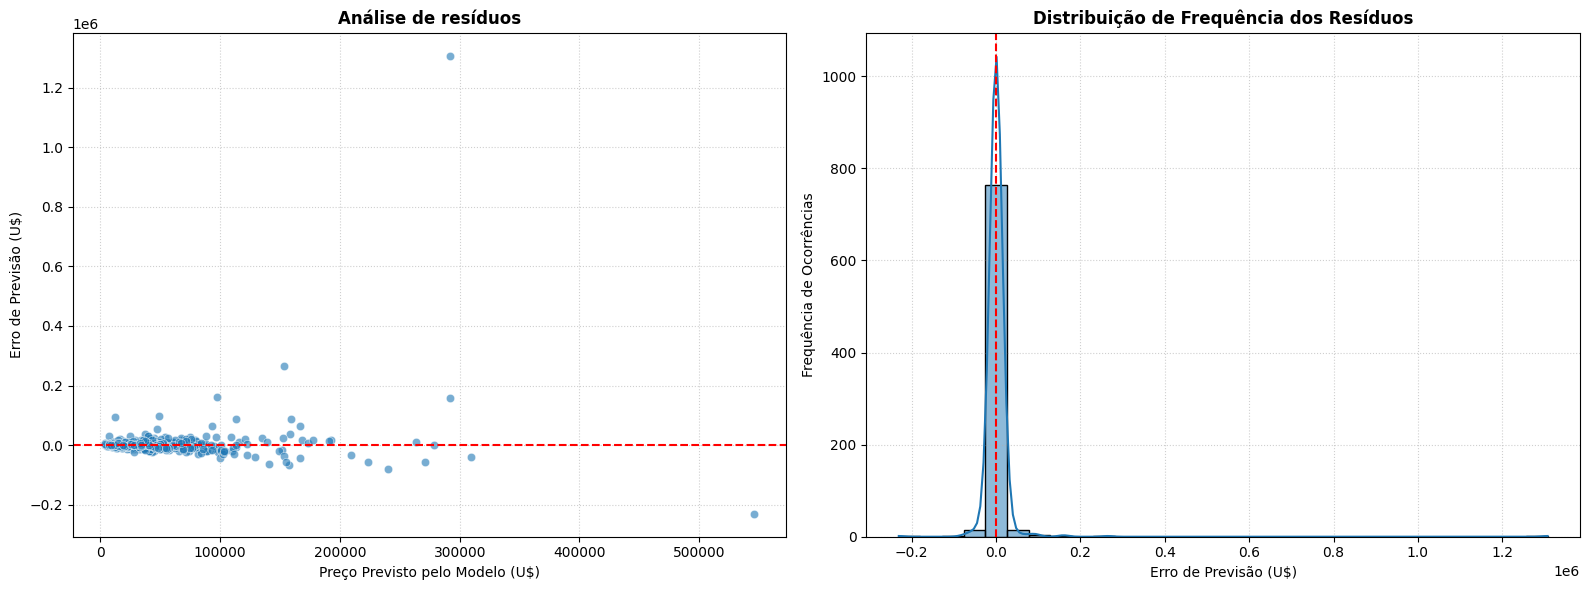

In [553]:
# Montagem de gráficos com o diagnóstico dos erros do modelo final

residuals = y_test - y_pred_xgb

# Cria a moldura dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Dispersão de Resíduos vs. Valores Previstos
sns.scatterplot(x=y_pred_xgb, y=residuals, ax=axes[0], alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Análise de resíduos", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Preço Previsto pelo Modelo (U$)", fontsize=10)
axes[0].set_ylabel("Erro de Previsão (U$)", fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico B: Histograma de Distribuição dos Erros
sns.histplot(residuals, kde=True, ax=axes[1], bins=30)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Distribuição de Frequência dos Resíduos", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Erro de Previsão (U$)", fontsize=10)
axes[1].set_ylabel("Frequência de Ocorrências", fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

A análise comparativa e a avaliação crítica dos erros no conjunto de teste consolidaram o diagnóstico final do modelo:

* Análise dos Ganhos e Eficácia das Métricas: O processo de otimização gerou uma evolução expressiva na capacidade preditiva do algoritmo frente a dados inéditos. O XGBoost Otimizado alcançou um MAPE final de 23,20% e um RMSE de 50,169,59 dólares, superando drasticamente o baseline ingênuo da mediana, que registrou 94,67% de MAPE e U$ 70.442,60 de RMSE. A combinação dessas duas métricas capturou bem o objetivo do problema: o MAPE validou a aderência comercial da precificação na maioria do catálogo (erros proporcionais controlados), enquanto o RMSE atuou como um "fiscal financeiro", expondo e penalizando severamente os desvios em valores absolutos (dólares) nos veículos de maior valor.

* Diagnóstico de Variância e Viés (Overfitting vs. Underfitting): O confronto entre as métricas das duas últimas etapas demonstra uma convergência estável. O modelo registrou um MAPE de 20,99% na validação cruzada e avançou para 23,20% no conjunto de teste. Esse acréscimo marginal de apenas 2,21 pontos percentuais evidencia um comportamento de baixa variância, indicando que o algoritmo não sofreu de overfitting (memorização do padrão de treino) e manteve sua integridade preditiva perante dados completamente inéditos. Da mesma forma, o distanciamento em relação ao baseline afasta a hipótese de alto viés (underfitting), ratificando a consistência e o forte poder de generalização da arquitetura final.

* Comportamento e Perfil dos Erros (Análise de Resíduos): A análise visual dos gráficos de resíduos revela que o modelo não comete erros homogêneos ao longo de toda a régua de preço. O modelo apresenta maior precisão e concentração de acertos em veículos de faixas de preço baixas e médias. Contudo, o gráfico de dispersão denuncia que os maiores erros (resíduos mais distantes da linha zero) ocorrem na subestimação ou superestimação de veículos de alto padrão. O histograma complementa esse diagnóstico, exibindo uma distribuição centralizada próxima a zero, mas com uma cauda longa à direita, confirmando que os grandes desvios absolutos estão concentrados em uma minoria de carros de luxo.

* Limitações de Dados e Riscos de Generalização: Existe um viés metodológico imposto pela natureza volumétrica da base de dados. Modelos de aprendizado de máquina baseados em árvores, como o XGBoost, dependem de densidade estatística para aprender. Como o mercado é composto majoritariamente por carros populares e intermediários, o modelo foi exposto a fatias massivas de dados desse segmento, gerando excelente generalização ali. Em contrapartida, a escassez de dados e a alta volatilidade de preços em nichos específicos (como carros superesportivos, relíquias ou veículos altamente customizados) impedem que o algoritmo mapeie perfeitamente essas regras de depreciação. Adicionalmente, a precisão do algoritmo encontra um gargalo intransponível na ausência de atributos qualitativos vitais para a precificação real, como o estado de conservação do veículo e o histórico de manutenção. Estes fatores representam os principais risco de generalização da solução.

* Cenários de Restrição de Uso: Com base nas limitações apontadas, o modelo atual não deve ser utilizado de forma automatizada para a precificação de veículos pertencentes ao segmento de altíssimo luxo (Luxury/Exotic), carros de colecionador ou modelos com baixa amostragem histórica, onde a raridade e o estado de conservação ditam a maior parte do valor de mercado. Para essa categoria de veículos, os erros absolutos apontados pelo RMSE podem resultar em prejuízos financeiros severos na operação de compra e venda. O uso do modelo nesses cenários deve ser restrito ou obrigatoriamente acompanhado por uma auditoria humana (avaliação de um especialista técnico), reservando a automação integral do algoritmo apenas para o catálogo de veículos comerciais e de grande circulação (Mainstream e Premium).

#12. Comparação final dos modelos

Após a execução das esteiras de validação e do torneio de algoritmos, os resultados consolidados apontam para uma evolução nítida em relação ao Baseline. Conforme determinado na seção 9.1, a hipótese de utilizar arquiteturas especialistas divididas por nicho de mercado foi formalmente rejeitada, uma vez que tais modelos trouxeram complexidade operacional e aumento no custo computacional sem gerar ganhos expressivos na capacidade de generalização global. Por utilizarem métricas agregadas por média ponderada, os modelos especialistas foram omitidos desta tabela para garantir a consistência de escala e a comparação justa entre os modelos generalistas concorrentes.

Dentre os modelos generalistas avaliados diretamente sobre a base unificada, o Bagging apresentou um RMSE competitivo, porém foi descartado devido ao seu alto custo computacional e extrema lentidão no treinamento (~24 segundos), o que inviabiliza sua escalabilidade. Já o Gradient Boosting (GBoosting) tradicional demonstrou boa precisão inicial, mas mostrou-se menos eficiente computacionalmente e com menor flexibilidade para controle de overfitting quando comparado à estrutura do XGBoost.

O confronto final consagrou a estratégia de otimização de hiperparâmetros em duas etapas (Randomized + Grid Search) aplicada ao modelo generalista. O XGBoost Otimizado atingiu o melhor desempenho absoluto do projeto, reduzindo o erro médio para o menor patamar encontrado (20.99% de MAPE e U$ 38,832.23 de RMSE), mantendo um tempo de treino altamente eficiente de cerca de 2 segundos. Por reunir precisão superior, velocidade de processamento, robustez contra overfitting e simplicidade para manutenção de pipeline em produção, este algoritmo foi o selecionado como a solução oficial para o MVP.

A tabela a seguir resume as métricas finais obtidas para as configurações testadas:

| Modelo | MAPE (%) | RMSE (U$) | Tempo de treino (s) | Observações |
|---|---:|---:|---:|---|
| Baseline | 92,64% | 68.080,66 | 2 | Modelo dummy baseado na mediana |
| GBoosting | 22,79% | 40.280,64 | 7 | Boa performance, mas menor eficiência e potencial de otimização que XGB |
| XGBoost | 22,79% | 39.703,08 | 2 | Melhor equilíbrio entre performance e eficiência |
| Bagging | 22,88% | 38.824,13 | 24 | Modelo de treinamento lento, alto custo computacional |
| XGB otimizado | 20,99% | 38.832,23 | 2,5 | Algoritmo escolhido, com parâmetros otimizados |

#13. Boas práticas e rastreabilidade

Para garantir a reprodutibilidade do projeto, documentamos a seguir as configurações do ambiente e a justificativa para cada decisão técnica tomada ao longo do MVP.

##13.1 Configurações Globais e Recursos Computacionais

* Mecanismo de Reprodutibilidade (Seed): Fixada em SEED = 7 para todas as operações que envolvem aleatoriedade.

* Ambiente de Execução e Recursos: Desenvolvido integralmente no ecossistema de nuvem do Google Colab. Utilizou-se a CPU padrão fornecida pelo ambiente gratuito, operando com alocação regular de memória RAM.

* Tempo Aproximado de Treinamento: A esteira de produção completa, englobando o pré-processamento de dados e a validação cruzada do modelo final otimizado, consome cerca de 2 segundos. O ciclo completo de otimização de hiperparâmetros (busca ampla e refinamento local) é concluído em cerca de 2 minutos.

* Limitações Conhecidas: Restrição temporal e geográfica da base (fotografia estática do mercado americano restrita ao ano de 2023) e ausência de atributos qualitativos vitais para a precificação de veículos usados, como o estado de conservação e o histórico de manutenção do automóvel.

##13.2 Registro de Decisões Metodológicas

A tabela abaixo compila as principais decisões tomadas durante o desenvolvimento do MVP, mapeando as justificativas técnicas e os impactos observados ou esperados no desempenho prático da solução, incluindo as abordagens que foram tentadas e descartadas.

| Decisão | Justificativa | Impacto esperado |
| :--- | :--- | :--- |
| **Usar o MAPE como métrica principal** | É fácil de interpretar pelo negócio, pois mostra o erro em porcentagem. | Avaliar o erro de forma proporcional, sem importar o preço do carro. |
| **Usar o RMSE como métrica secundária** | Monitorar e penalizar os maiores erros em valores absolutos (dólares). | Identificar se o modelo está errando feio em carros muito caros. |
| **Conversão de tipo das colunas `milage` e `price`** | Os dados originais continham caracteres de texto (como "mi" e "U$"), impedindo cálculos matemáticos. | Garantir que o Python reconheça as variáveis como numéricas antes de qualquer análise ou modelagem. |
| **Imputação de nulos em `fuel_type` por 'Electric'** | A análise do motor mostrou que todos os carros com combustível nulo eram elétricos. | Correção lógica dos dados sem causar vazamento (*data leakage*). |
| **Imputação de nulos em `accident` por 'None reported'** | A mediana de preço dos carros nulos era quase igual à dos carros sem acidentes. | Preservação de 3% das linhas da base mantendo a lógica de mercado. |
| **Remover a coluna `clean_title`** | Tinha 15% de dados nulos e o teste mostrou que preenchê-los distorcia os preços. | Redução de ruído e eliminação de uma variável sem padrão lógico. |
| **Agregação de classes em variáveis categóricas** | Colunas `brand`, `fuel_type`, `engine`, `transmission`, `ext_col` e `int_col` tinham muitas categorias. | Reduzir a dimensionalidade e criar grupos mais densos e fáceis de o modelo aprender. |
| **Transformar `model_year` em `vehicle_age`** | O ano de fabricação isolado não reflete diretamente o desgaste temporal do carro. | Criar um atributo numérico linear que represente a idade real do veículo, facilitando a correlação com o preço. |
| **Remover outliers via IQR em `milage` e `vehicle_age`** | Carros muito velhos ou muito rodados têm poucos dados e preço imprevisível. | Evitar que dados extremos atrapalhem o aprendizado do modelo no mercado comum. |
| **Manutenção de extremos em `engine_hp` e `engine_displacement`** | Motores potentes e grandes são reais e justificam carros mais caros. | Permitir que o modelo aprenda a diferença entre carros populares e esportivos. |
| **Tratar o preço (`price`) via escala logarítmica** | O dataset tem poucos carros de superluxo que puxam a média muito para cima. | Estabilizar a variação dos preços no treino sem precisar apagar os carros caros. |
| **Aplicar *Target Encoding* na variável `model`** | A coluna tinha quase 1.900 nomes de modelos para apenas 4.009 instâncias. | Substituir o texto pela média de preço de cada modelo, evitando criar milhares de colunas. |
| **Uso do parâmetro `drop='first'` no *Dummy Encoding*** | Evitar problemas de correlação perfeita entre colunas categóricas menores. | Garantir a estabilidade matemática para os modelos lineares do torneio. |
| **Aplicar normalização (*StandardScaler*) nos dados** | Algoritmos como os lineares e KNN são sensíveis a variáveis com escalas muito diferentes. | Colocar todos os recursos na mesma escala para garantir um torneio justo e sem distorções. |
| **Fazer validação cruzada com 10 *folds*** | Uma divisão simples de treino e validação poderia gerar resultados instáveis pela variação da base. | Garantir uma avaliação robusta e confiável do poder de generalização de cada algoritmo. |
| **Escolha do baseline como modelo dummy (mediana)** | Necessidade de um ponto de partida simples e ingênuo para validar se o uso de ML faz sentido. | Servir como referência mínima de desempenho para os modelos candidatos. |
| **Descartar modelos lineares após o torneio** | Tiveram desempenho ruim (*underfitting*), chegando a erros na casa dos milhões de dólares. | Proteger o projeto contra modelos incapazes de lidar com preços complexos. |
| **Descartar os demais candidatos, exceto o top 3 *ensembles*** | Modelos mais simples como KNN e árvores puras não atingiram o patamar de erro aceitável. | Filtrar apenas os algoritmos baseados em comitês (XGBoost, GBoosting e Bagging) para a fase de refinamento. |
| **Descartar o algoritmo Bagging** | Demorou cerca de 24 segundos para treinar, sendo o mais lento do torneio. | Evitar desperdício de recurso computacional por um ganho muito pequeno. |
| **Escolha do XGBoost como modelo final** | Teve o melhor MAPE (22,79%), foi o mais rápido (~2 segundos) e oferece maior flexibilidade para otimização e controle de overfitting. | Modelo preciso, leve para atualizar, flexível para ajuste fino e rápido para rodar em produção.
| **Rejeitar a estratégia de Modelos Especialistas** | O ganho foi menor que 0,5 p.p. e o segmento de luxo piorou por ter poucos dados. | Manter o projeto simples com apenas 1 modelo global em vez de 3. |
| **Abordagem de otimização híbrida em duas etapas** | Rodar uma busca exaustiva (Grid Search) logo de início demoraria demais. | Achar os melhores parâmetros combinando velocidade e precisão em cerca de 2 minutos. |
| **Manter a floresta com 133 árvores** | Mudar para 300 árvores melhoraria o erro em apenas 0,14 p.p., exigindo o dobro de treino. | Escolha do modelo mais simples e eficiente, seguindo a lógica de parcimônia. |


#14. Conclusão

Este MVP teve como objetivo criar um modelo de regressão para estimar o preço de carros usados no mercado americano, servindo como uma ferramenta de apoio para vendedores individuais. O problema original era a dificuldade de definir um preço competitivo sem perder margem de lucro ou estender o tempo de anúncio. O projeto buscou resolver isso substituindo estimativas intuitivas por uma previsão baseada em dados reais de quilometragem, idade, motor, histórico de acidentes, entre outros.

O melhor modelo encontrado foi o XGBoost Genérico, ajustado em duas etapas de otimização (Random Search e Grid Search) e aplicando a escala logarítmica na variável de preço. No conjunto de teste, com dados inéditos, o modelo alcançou um MAPE de 23,20% e um RMSE de USD 50.169,59. Esse resultado atendeu a todos os critérios de sucesso estabelecidos no início do projeto: o MAPE final ficou abaixo do teto estipulado de 25%, e o RMSE foi reduzido em 28,77% em relação ao baseline ingênuo (Dummy Mediana), superando a meta mínima de 20% de melhoria. Além disso, a restrição prática de custo computacional foi plenamente respeitada, já que o pipeline completo executa em cerca de 2 segundos. Na prática, enquanto o baseline de 94,67% de MAPE inviabilizaria a operação por errar quase o valor inteiro do veículo, o XGBoost Otimizado traz o erro para a casa dos 23%, uma margem competitiva e compatível com as negociações reais do mercado de usados.

Os principais aprendizados deste trabalho revelaram que o preço de um automóvel é um fenômeno não linear e multivariado. A hipótese de que regras ou variáveis isoladas explicariam a depreciação foi refutada na análise exploratória e consolidada no torneio de algoritmos, onde os modelos lineares sofreram underfitting devido à incapacidade de lidar com a alta dimensionalidade e com a variância extrema dos dados. O topo da tabela foi dominado por comitês de árvores (Ensembles), que provaram sua robustez ao capturar de forma nativa as interações complexas entre as características do veículo (como idade e quilometragem) e o prêmio por exclusividade de marca. Outro aprendizado crítico partiu do teste da estratégia de modelos especialistas por segmento de marca, que acabou rejeitada. A especialização gerou um ganho marginal nas categorias de massa e degradou a precisão no nicho de luxo devido à escassez de dados, provando que um modelo generalista estabiliza melhor as previsões ao compartilhar o aprendizado das regras gerais de desvalorização do ecossistema.

Apesar do sucesso preditivo nos segmentos de volume, o MVP apresenta limitações conhecidas que delimitam suas fronteiras de atuação. Por se basear em uma fotografia estática do marketplace Cars.com restrita ao ano de 2023, o algoritmo possui uma restrição geográfica e temporal evidente, não sendo diretamente aplicável ao cenário econômico brasileiro ou a períodos posteriores. Além disso, os modelos de aprendizado de máquina encontraram um gargalo na ausência de dados qualitativos fundamentais na jornada de compra de um usado, tais como o estado de conservação do veículo, a presença de avarias e o histórico de revisões mecânicas. Essa carência de dados explica por que o RMSE global foi severamente impactado pelo segmento de luxo, onde a subjetividade e a raridade ditam o preço, gerando cenários de restrição de uso onde a automação do modelo deve ser obrigatoriamente acompanhada por uma auditoria humana.

Como próximos passos para a evolução do projeto, recomenda-se a ampliação contínua da base de dados ao longo do tempo, permitindo que o modelo capture variações sazonais e novas tendências de mercado. Além disso, sugere-se o enriquecimento das informações por meio da inclusão de atributos qualitativos sobre o estado de conservação e o histórico mecânico dos veículos. Essas ações poderiam reduzir os erros de previsão nos segmentos mais caros sem a necessidade de aumentar a complexidade da estrutura do pipeline.